# Analysis of networks of persons in relation to organisations


Cf. [this notebook](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/analyse_reseaux/reseaux_florence.ipynb) about families and power in Renaissance Florence for an introduction to network analysis with the *networkx* Python library



In [1]:
import pandas as pd


import networkx as nx
from networkx.algorithms import bipartite

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator

from scipy.stats import spearmanr
import statsmodels.api as sm

import numpy as np
import seaborn as sns
import math
import os

In [2]:
### Librairies déjà installées avec Python
import pprint
import csv

import sqlite3 as sql

### this library allows to do SQL queries on dataframes
import duckdb

import pickle

import time
import datetime
from dateutil import parser


from shutil import copyfile


In [ ]:
### Importing a custom function module
##  NOTE: The ‘sparql_functions.py’ file must be located 
#   in a folder that is included in the search path
#   recognized by this Jupyter notebook so that
#   the import works correctly

import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [4]:

import network_analysis_functions as naf
import bivariate_library as bl

In [5]:
print(reload(bl))  

<module 'bivariate_library' from '/home/francesco/kDrive/python_notebooks/astronomers/notebooks_jupyter/wikidata_exploration/../bivariate_library.py'>


In [6]:
import warnings
warnings.filterwarnings('ignore')


## Get and inspect the data


### Get the network data

We use here the network data prepared in this notebook 
* Get the [Network creation](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/notebooks_jupyter/wikidata_exploration/da6-persons-network-creation.ipynb)

In [7]:
### Upload the network prepared in the Network creation

file_address='da_data/da6-networks.pkl'
network=pd.read_pickle(file_address)
print(len(network))
network.iloc[:3]

1075467


,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Hans Elsässer,Willi Kalender,1929,1949,1951-1975,1976-2000,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100216
1,Hans Elsässer,Werner Känzig,1929,1922,1951-1975,1951-1975,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q102226864
2,Hans Elsässer,Aage Bohr,1929,1922,1951-1975,1951-1975,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q103854


#### Swap the values in order to have always older person in position x

We want to have the older person always in the in the first position.

This will be useful when coloring the network's edges: you then have to choose between one of the two persons and this gives the direction of the flow of time

In [9]:
### Get the rows where persons chronologically inversed
inverse_df=network[network['per_activ_x']>network['per_activ_y']]
print(len(inverse_df))
inverse_df.head()

253989


,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
49,Hans Elsässer,Paul Görlich,1929,1905,1951-1975,1926-1950,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q15435012
78,Hans Elsässer,Emilio G. Segrè,1929,1905,1951-1975,1926-1950,0,1,0,NaN,0,NaN,1,Heidelberg Academy of Sciences and Humanities,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q173028
87,Hans Elsässer,Nevill Francis Mott,1929,1905,1951-1975,1926-1950,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q189485
138,Hans Elsässer,Bernhard Haurwitz,1929,1905,1951-1975,1926-1950,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q4894181
158,Hans Elsässer,Albrecht Unsöld,1929,1905,1951-1975,1926-1950,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q62722


In [10]:
### Copy networks to work on copies
df = network.copy()
df_new = network.copy()

In [11]:
### Swap only the rosw in index


# The specific indices where the swap must occur
indices_to_swap = inverse_df.index


# Identify all column pairs (_x and _y) dynamically
x_cols = [col for col in df.columns if col.endswith('_x')]
pairs = []
for x_col in x_cols:
    base = x_col.replace('_x', '')
    y_col = f"{base}_y"
    if y_col in df.columns:
        pairs.append((x_col, y_col))

# Perform the swap ONLY for the rows in indices_to_swap
for x_col, y_col in pairs:
    # Extract values at the specific indices
    vals_x = df_new.loc[indices_to_swap, x_col].values
    vals_y = df_new.loc[indices_to_swap, y_col].values
    
    # Assign swapped values back to the same specific indices
    df_new.loc[indices_to_swap, x_col] = vals_y
    df_new.loc[indices_to_swap, y_col] = vals_x

# df_new now has swapped values for rows in index
# All other rows remain exactly as they were in the original df

##### Check swap result

In [12]:
## example
ii=inverse_df.sort_values(by='sum_edu_empl', ascending=False).index
print(ii[2000:2005])

Index([920799, 920766, 163607, 163582, 681146], dtype='int64')


In [13]:
df_new.iloc[ii[2000:2005]]

,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
920799,Samuel Goudsmit,Ernest Courant,1902,1920,1926-1950,1951-1975,1,2,0,NaN,1,Brookhaven National Laboratory,1,National Academy of Sciences,http://www.wikidata.org/entity/Q560839,http://www.wikidata.org/entity/Q441738
920766,Brian O'Brien,Ernest Courant,1898,1920,1926-1950,1951-1975,1,2,0,NaN,1,University of Rochester,1,National Academy of Sciences,http://www.wikidata.org/entity/Q4964888,http://www.wikidata.org/entity/Q441738
163607,Jacek Prentki,Józef Smak,1920,1936,1951-1975,1976-2000,1,1,0,NaN,1,University of Warsaw,0,NaN,http://www.wikidata.org/entity/Q2732848,http://www.wikidata.org/entity/Q11731370
163582,Włodzimierz Zonn,Józef Smak,1905,1936,1926-1950,1976-2000,1,1,0,NaN,1,University of Warsaw,0,NaN,http://www.wikidata.org/entity/Q2580774,http://www.wikidata.org/entity/Q11731370
681146,Pol Duwez,Stanley Deser,1907,1931,1951-1975,1976-2000,1,2,0,NaN,1,California Institute of Technology,1,National Academy of Sciences,http://www.wikidata.org/entity/Q7208808,http://www.wikidata.org/entity/Q2331679


In [14]:
network.iloc[ii[2000:2005]]

,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
920799,Ernest Courant,Samuel Goudsmit,1920,1902,1951-1975,1926-1950,1,2,0,NaN,1,Brookhaven National Laboratory,1,National Academy of Sciences,http://www.wikidata.org/entity/Q441738,http://www.wikidata.org/entity/Q560839
920766,Ernest Courant,Brian O'Brien,1920,1898,1951-1975,1926-1950,1,2,0,NaN,1,University of Rochester,1,National Academy of Sciences,http://www.wikidata.org/entity/Q441738,http://www.wikidata.org/entity/Q4964888
163607,Józef Smak,Jacek Prentki,1936,1920,1976-2000,1951-1975,1,1,0,NaN,1,University of Warsaw,0,NaN,http://www.wikidata.org/entity/Q11731370,http://www.wikidata.org/entity/Q2732848
163582,Józef Smak,Włodzimierz Zonn,1936,1905,1976-2000,1926-1950,1,1,0,NaN,1,University of Warsaw,0,NaN,http://www.wikidata.org/entity/Q11731370,http://www.wikidata.org/entity/Q2580774
681146,Stanley Deser,Pol Duwez,1931,1907,1976-2000,1951-1975,1,2,0,NaN,1,California Institute of Technology,1,National Academy of Sciences,http://www.wikidata.org/entity/Q2331679,http://www.wikidata.org/entity/Q7208808


In [14]:
### Replace the original network

network=df_new


### Get the data about persons


#### Get the individuals (20000) used for correspondence analysis 


In [240]:
### Information about persons with gender, birth date,
# coded country, etc.
csv_address='da_data/da4-AFC.csv'
### csv_address='da_data/da2-birth-place.csv'
df_p = pd.read_csv(csv_address)
df_p=df_p[['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'REGION', 'NAME_ENGL', 'coded_country', 'periodsActivity']]
### Rename columns to have shorter labels
df_p.columns=['person_uri',
 'labelPer',
 'birthYear',
 'gender',
 'labelPlace',
 'REGION',
 'NAME_ENGL',
 'country',
 'per_activ'
 ]


In [241]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20043 entries, 0 to 20042
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   person_uri  20043 non-null  object
 1   labelPer    20043 non-null  object
 2   birthYear   20043 non-null  int64 
 3   gender      20043 non-null  object
 4   labelPlace  20043 non-null  object
 5   REGION      20043 non-null  object
 6   NAME_ENGL   20043 non-null  object
 7   country     20043 non-null  object
 8   per_activ   20043 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.4+ MB


In [242]:
print(len(df_p))
df_p.iloc[:3]

20043


,person_uri,labelPer,birthYear,gender,labelPlace,REGION,NAME_ENGL,country,per_activ
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,Western Europe,France,France,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,Western Europe,Germany,Germany,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,Eastern Europe,Ukraine,Ukraine,1826-1850


## Create the graphs

We will now transform our networks into graphs using the Python *networkx* library

In [21]:
network.iloc[:2]

,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Hans Elsässer,Willi Kalender,1929,1949,1951-1975,1976-2000,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100216
1,Hans Elsässer,Werner Känzig,1929,1922,1951-1975,1951-1975,0,1,0,NaN,0,NaN,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q102226864


### Education

In [22]:
### Take all the relathioships with an educational link 
ntwk_edu=network[network.orgs_number_edu>0][['labelPer_x', 'labelPer_y', 'birthYear_x', 'birthYear_y', 'per_activ_x', 'per_activ_y', 'sum_edu_empl', 'sum_all_rel', 'orgs_number_edu', 'orgs_labels_edu','person_uri_x', 'person_uri_y']]
print(len(ntwk_edu))
ntwk_edu.iloc[:2]


33071


,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,person_uri_x,person_uri_y
139,Hans Elsässer,Betsy Ancker-Johnson,1929,1927,1951-1975,1951-1975,1,1,1,University of Tübingen,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q4898262
610,Edgar Knobloch,Saul Perlmutter,1953,1959,1976-2000,2001-2025,2,2,1,Harvard University,http://www.wikidata.org/entity/Q100155322,http://www.wikidata.org/entity/Q106949


In [23]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     {'orgsLabels':e['orgs_labels_edu'], 'orgsNumber':e['orgs_number_edu'],
      'per_activ_x':e['per_activ_x'], 'per_activ_y':e['per_activ_y']}
     )) 
     for e in ntwk_edu.to_dict(orient='records')]
print(len(l))

33071


In [24]:
## Créate the empty graph
G_edu=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_edu.add_edges_from(l)

naf.basic_graph_properties(G_edu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 4939,
 'number_of_edges': 33071,
 '------': '------',
 'is connected': False,
 'components': 229,
 'density': 0.0027119845509300136}


#### Add metadata to nodes

In [25]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,REGION,NAME_ENGL,country,per_activ,occup_m,occup_s,empl
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,Western Europe,France,France,1826-1850,astronomer,mathematician,agency
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,Western Europe,Germany,Germany,1826-1850,,,


In [26]:
df_pm = df_p[['person_uri','labelPer', 'birthYear', 'gender','per_activ','country']]
df_pm = df_pm.drop_duplicates()
df_pm.columns=['uri', 'label', 'birthYear', 'gender','per_activ','country']
df_pm.head()


,uri,label,birthYear,gender,per_activ,country
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,1826-1850,France
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,1826-1850,Germany
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,1826-1850,Ukraine
3,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,1826-1850,Germany
4,http://www.wikidata.org/entity/Q22331669,Carlo Brioschi,1782,male,1826-1850,Italy


In [27]:
### Prepare data to add to nodes
# The data must be of type : dictionary, i.e. key:value structure
ln = dict([(e['uri'],
     {'label':e['label'], 
       'birthYear':e['birthYear'],
       'gender':e['gender'],
       'per_activ':e['per_activ'],
      'country':e['country']}
     ) for e in df_pm.to_dict(orient='records')])
# print(str(l)[:200])


In [28]:

## Add attributes
nx.set_node_attributes(G_edu, ln)
pprint.pprint(list(G_edu.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000193',
  {'birthYear': 1929,
   'country': 'Germany',
   'gender': 'male',
   'label': 'Hans Elsässer',
   'per_activ': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q4898262',
  {'birthYear': 1927,
   'country': 'United States Can.',
   'gender': 'female',
   'label': 'Betsy Ancker-Johnson',
   'per_activ': '1951-1975'})]


In [29]:
naf.basic_graph_properties(G_edu)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 4939,
 'number_of_edges': 33071,
 '------': '------',
 'is connected': False,
 'components': 229,
 'density': 0.0027119845509300136}


#### Edu Components

This graph isn't connected. This means that there are parts of the graph, called 'components', that are separated from other parts.

In [33]:
### Create a list of graphs, one per component
perS_edu = [G_edu.subgraph(c).copy() for c in nx.connected_components(G_edu)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
lc = sorted([[i,len(s.nodes)] for i,s in enumerate(perS_edu)], key = lambda row: row[1], reverse=True)
print(lc[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[1, 4175], [2, 33], [48, 28], [36, 18], [26, 17]]


### Explore small graph

In [34]:
### 
li = [2]    # [48,36, ..]
ll = [list(perS_edu[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [35]:

# Display variable

variable_name = 'edu_2'

globals()[variable_name] = nx.Graph()

edu_gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    edu_gu = nx.union(edu_gu, perS_edu[i])
naf.basic_graph_properties(edu_gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 33,
 'number_of_edges': 268,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.5075757575757576}


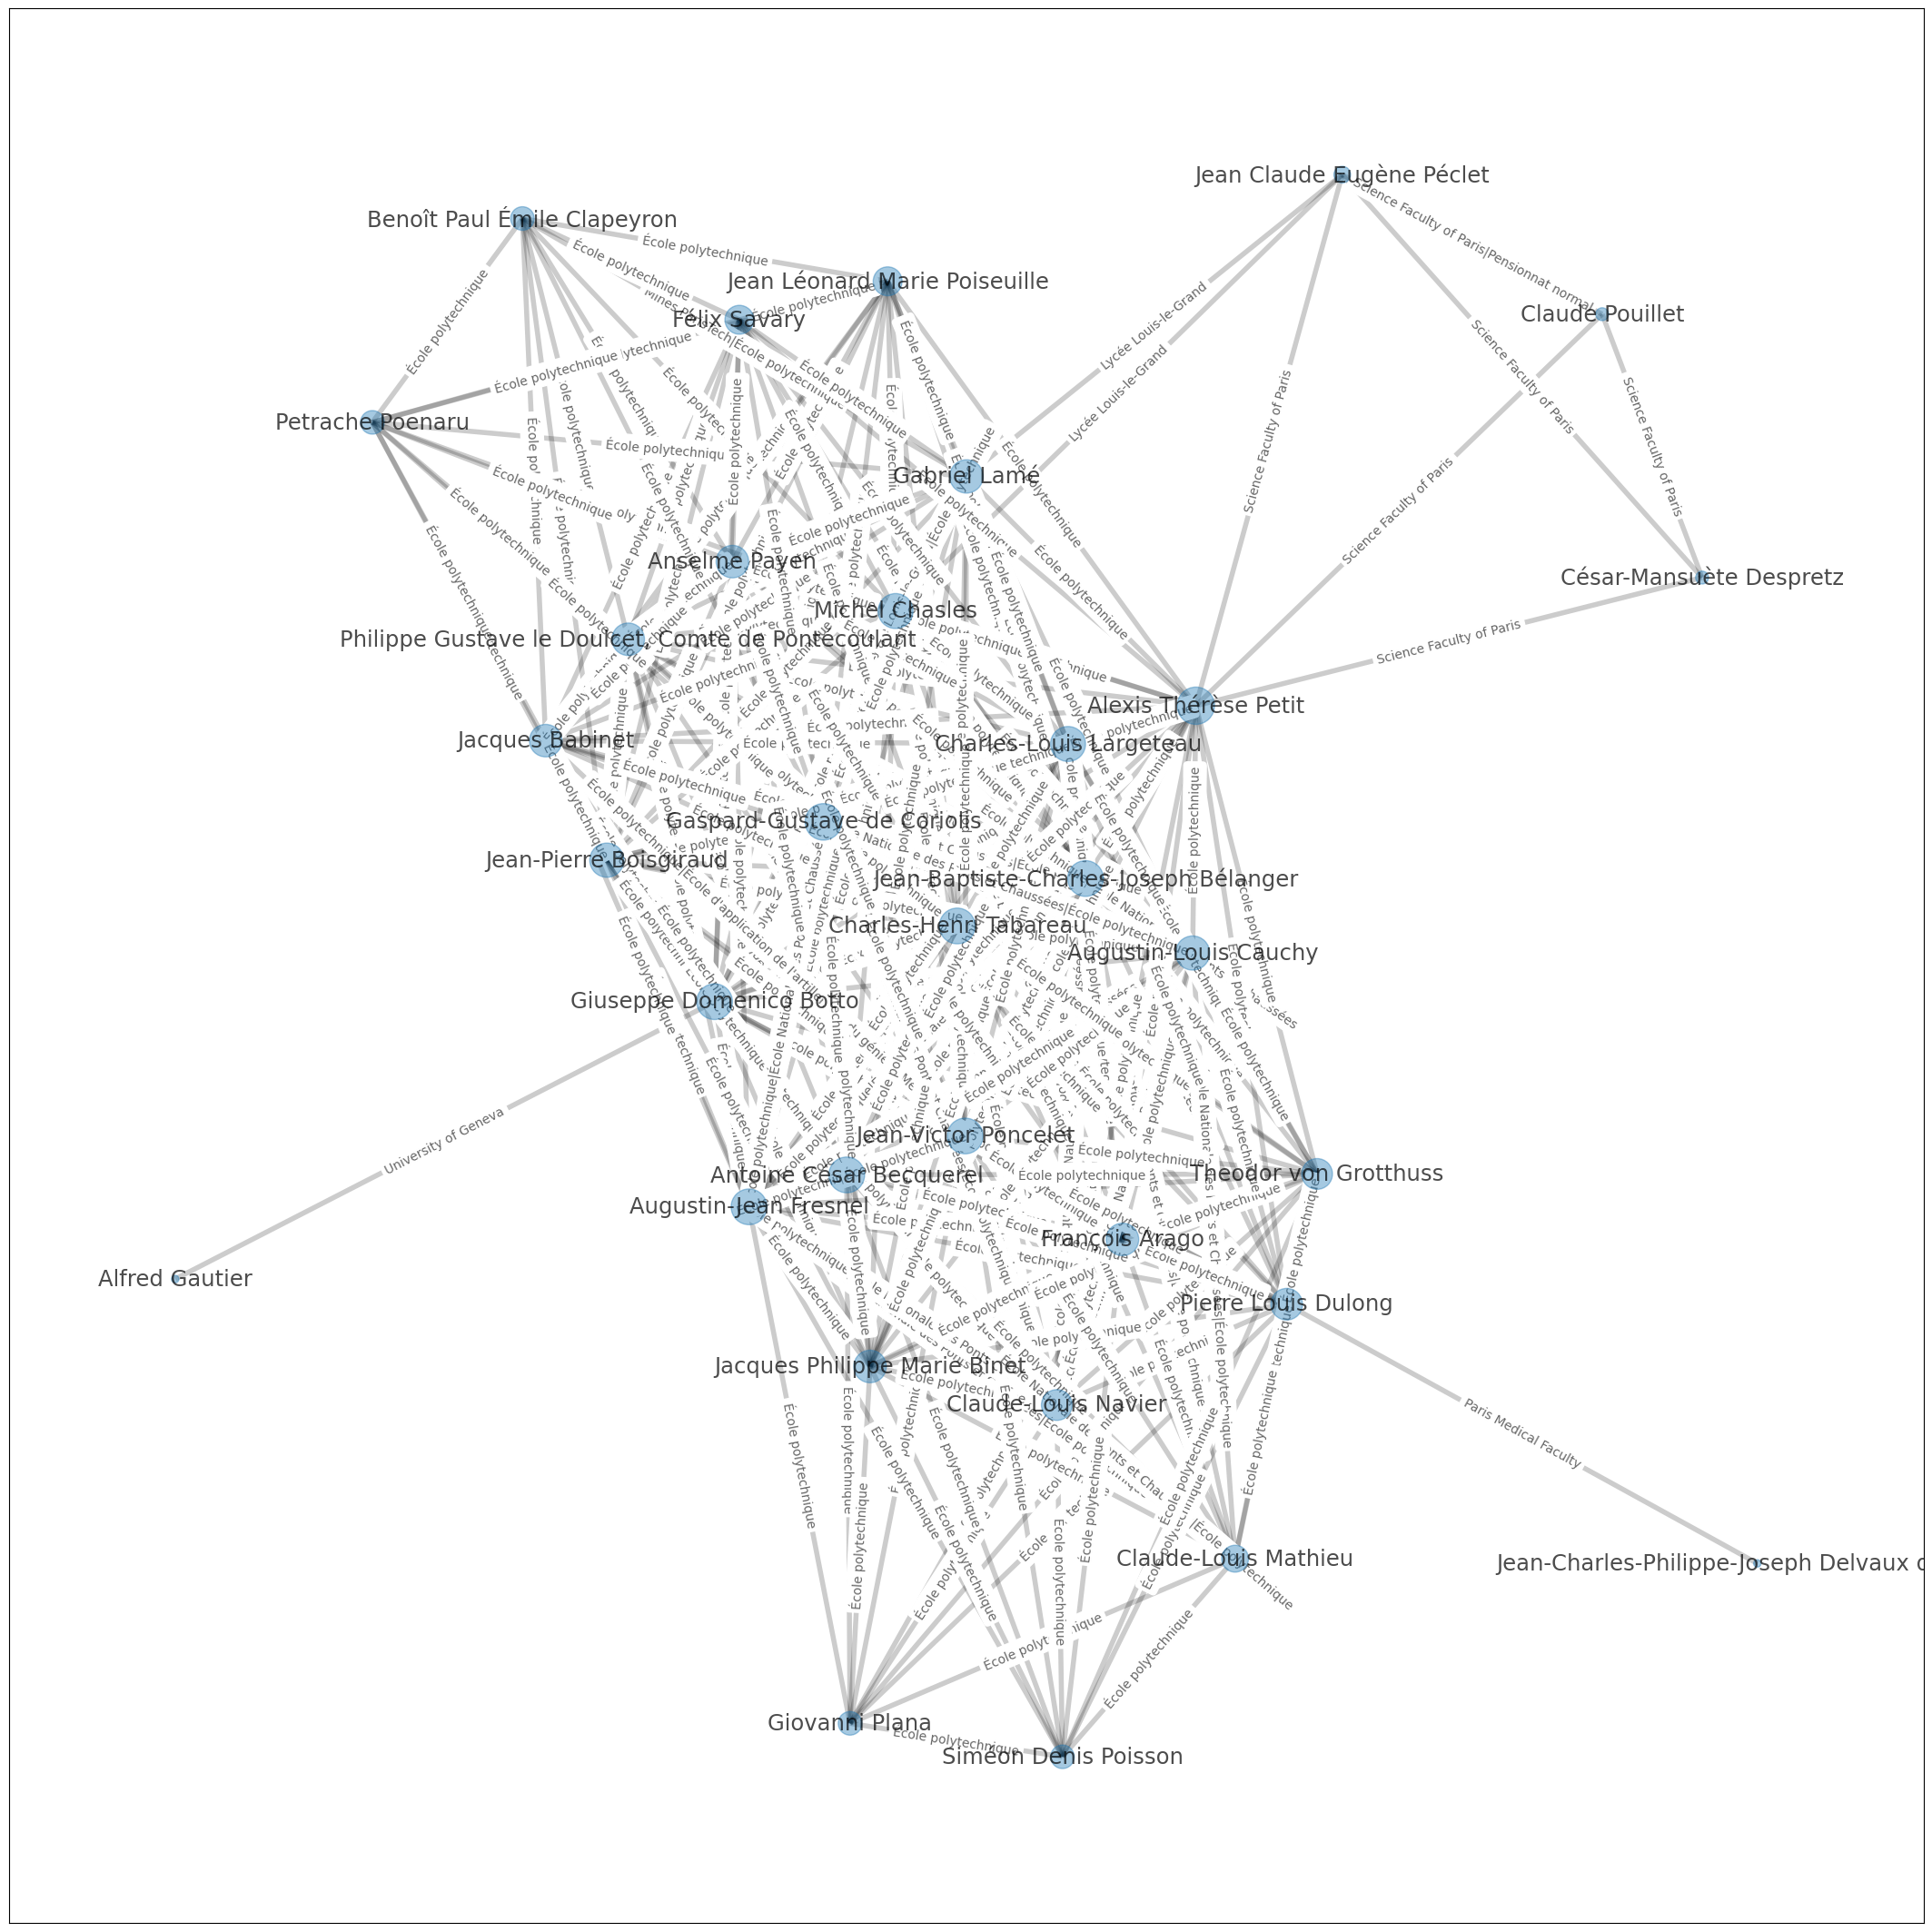

In [36]:
### Draw graph with networkx



# print(list(g.nodes.data())[:3])
# print(list(g.edges.data())[:3])

n_size = np.log(np.sqrt(nx.number_of_nodes(edu_gu)))*20 #*25

graph_layout = 'kamada_kawai'
n_k = 0.4
sc = 0.02

### Define the layout, i.e. the choice 
# of the algorithm for the representation of the graph.

if graph_layout == 'fruchterman_reingold':
    pos = nx.fruchterman_reingold_layout(edu_gu)
elif graph_layout == 'kamada_kawai':
    pos = nx.kamada_kawai_layout(edu_gu)
elif graph_layout == 'spring_layout':
    pos = nx.spring_layout(g, k = n_k, scale=sc)  
else:
    pos = nx.kamada_kawai_layout(edu_gu)


# https://networkx.org/documentation/stable/reference/drawing.html
plt.figure(figsize = (n_size,n_size))

node_size = [d[1]*n_size for d in nx.degree(edu_gu)]
node_labels = dict([tuple(( n[0] , n[1]['label'] ))for n in edu_gu.nodes.data()])
#print(node_labels)
edge_labels = {e: edu_gu.get_edge_data(e[0], e[1])["orgsLabels"] for e in edu_gu.edges()}
#print(edge_labels)


### On représente successivement les différentes sommets et arêtes,
# puis on ajoute les labels
nx.draw_networkx_nodes(edu_gu, pos,  node_size=node_size, alpha=0.4)
nx.draw_networkx_edges(edu_gu, pos, label=edge_labels, width=4, alpha=0.2) # edgelist=ln, edge_color=c, 
nx.draw_networkx_labels(edu_gu, pos, labels=node_labels, alpha=0.7, font_size=n_size/2)
nx.draw_networkx_edge_labels(edu_gu, pos=pos, edge_labels=edge_labels, alpha=0.6)

### On peut augmenter ou diminuer ce paramètre pour ajuster le graphe
plt.tight_layout(pad=50)
#plt.savefig('images/small_bipartite_component.svg')
plt.show()


### Explore with Gephi online

* export the graph in the Gephi format
* explore it uploading the file into the [Gephi Web User Interface](https://lite.gephi.org)
* use the ForceAtlas2 algorythm: first click on the 'magic' button (left of the 'Start' button) then on Start

In [38]:
### Graph to heavy to use Gephy online
nx.write_gexf(edu_gu, f"da_graphs/{variable_name}.gexf")

### Main component

In [37]:
### Get the list of the nodes in the main component
li = [1]    
ll = [list(perS_edu[i[1]].nodes.data()) for i in ln if i[1] in li]

In [39]:

# Display variable

variable_name = 'edu_2'

globals()[variable_name] = nx.Graph()

edu_gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    edu_gu = nx.union(edu_gu, perS_edu[i])
naf.basic_graph_properties(edu_gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 4175,
 'number_of_edges': 31970,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.003669135136530963}


In [40]:
pprint.pprint(list(edu_gu.nodes.data())[2:4])

[('http://www.wikidata.org/entity/Q1173616',
  {'birthYear': 1958,
   'country': 'United States Can.',
   'gender': 'male',
   'label': 'David B. Kaplan',
   'per_activ': '2001-2025'}),
 ('http://www.wikidata.org/entity/Q1384920',
  {'birthYear': 1959,
   'country': 'United States Can.',
   'gender': 'male',
   'label': 'Steven H. Strogatz',
   'per_activ': '2001-2025'})]


In [41]:
### Graph to heavy to use Gephy online
# nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

### Employment graph

In [42]:
### Take all the relathioships with an educational link 
ntwk_empl=network[network.orgs_number_empl>0][['labelPer_x', 'labelPer_y', 'birthYear_x', 'birthYear_y', 'per_activ_x', 'per_activ_y', 'sum_edu_empl', 'sum_all_rel', 'orgs_number_empl', 'orgs_labels_empl','person_uri_x', 'person_uri_y']]
print(len(ntwk_empl))
ntwk_empl.iloc[:2]


103160


,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_empl,orgs_labels_empl,person_uri_x,person_uri_y
239,Charles Christian Lauritsen,John B. Irwin,1892,1909,1926-1950,1951-1975,1,1,1,California Institute of Technology,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q111028460
244,Charles Christian Lauritsen,Fritz Zwicky,1892,1898,1926-1950,1926-1950,1,1,1,California Institute of Technology,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q115462


In [43]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     { 'orgsLabels':e['orgs_labels_empl'], 'orgsNumber':e['orgs_number_empl'],   
      'periods_x':e['per_activ_x'], 'periods_y':e['per_activ_y']}
     )) 
     for e in ntwk_empl.to_dict(orient='records')]
print(len(l))

103160


In [44]:
## Créate the empty graph
G_empl=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_empl.add_edges_from(l)

naf.basic_graph_properties(G_empl)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 5098,
 'number_of_edges': 103160,
 '------': '------',
 'is connected': False,
 'components': 50,
 'density': 0.00794011631392954}


In [45]:
### Add person attributes to nodes

## the ln list was prepared above

## Add attributes
nx.set_node_attributes(G_empl, ln)
pprint.pprint(list(G_empl.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000934',
  {'birthYear': 1892,
   'country': 'Scandinavia',
   'gender': 'male',
   'label': 'Charles Christian Lauritsen',
   'per_activ': '1926-1950'}),
 ('http://www.wikidata.org/entity/Q111028460',
  {'birthYear': 1909,
   'country': 'United States Can.',
   'gender': 'male',
   'label': 'John B. Irwin',
   'per_activ': '1951-1975'})]


In [46]:
### Create a list of graphs, one per component
perS_empl = [G_empl.subgraph(c).copy() for c in nx.connected_components(G_empl)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
lc = sorted([[i,len(s.nodes)] for i,s in enumerate(perS_empl)], key = lambda row: row[1], reverse=True)
print(lc[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[0, 4978], [2, 8], [5, 4], [17, 4], [24, 4]]


#### Main component

In [47]:
### 
li = [0]    # [15, 33, 30]
ll = [list(perS_empl[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [48]:

# Display variable

variable_name = 'empl_0'

globals()[variable_name] = nx.Graph()

empl_gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    empl_gu = nx.union(empl_gu, perS_empl[i])
naf.basic_graph_properties(empl_gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 4978,
 'number_of_edges': 103063,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.008319749352445113}


### Membership graph

In [ ]:
### Take all the relathioships with an educational link 
ntwk_memb=network[network.orgs_number_memb>0][['labelPer_x', 'labelPer_y', 'birthYear_x', 
                                               'birthYear_y', 'per_activ_x', 'per_activ_y', 
                                               'sum_edu_empl', 'sum_all_rel', 
                                               'orgs_number_memb', 'orgs_labels_memb','person_uri_x', 'person_uri_y']]
print(len(ntwk_memb))
ntwk_memb.iloc[:2]


997706


,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Hans Elsässer,Willi Kalender,1929,1949,1951-1975,1976-2000,0,1,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100216
1,Hans Elsässer,Werner Känzig,1929,1922,1951-1975,1951-1975,0,1,1,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q102226864


In [ ]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     { 'orgsLabels':e['orgs_labels_memb'], 'orgsNumber':e['orgs_number_memb'],   
      'periods_x':e['per_activ_x'], 'periods_y':e['per_activ_y']}
     )) 
     for e in ntwk_memb.to_dict(orient='records')]
print(len(l))

997706


In [51]:
## Créate the empty graph
G_memb=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_memb.add_edges_from(l)

naf.basic_graph_properties(G_memb)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 6506,
 'number_of_edges': 997706,
 '------': '------',
 'is connected': False,
 'components': 31,
 'density': 0.04714886252930837}


In [52]:
### Add person attributes to nodes

## the ln list was prepared above

## Add attributes
nx.set_node_attributes(G_memb, ln)
pprint.pprint(list(G_memb.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000193',
  {'birthYear': 1929,
   'country': 'Germany',
   'gender': 'male',
   'label': 'Hans Elsässer',
   'per_activ': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100216',
  {'birthYear': 1949,
   'country': 'Germany',
   'gender': 'male',
   'label': 'Willi Kalender',
   'per_activ': '1976-2000'})]


In [53]:
### Create a list of graphs, one per component
perS_memb = [G_memb.subgraph(c).copy() for c in nx.connected_components(G_memb)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
lc = sorted([[i,len(s.nodes)] for i,s in enumerate(perS_memb)], key = lambda row: row[1], reverse=True)
print(lc[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[0, 6434], [9, 6], [21, 5], [2, 3], [3, 3]]


#### Main component

In [54]:
### 
li = [0]    # [15, 33, 30]
ll = [list(perS_memb[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [55]:

# Display variable

variable_name = 'memb_0'

globals()[variable_name] = nx.Graph()

memb_gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    memb_gu = nx.union(memb_gu, perS_memb[i])
naf.basic_graph_properties(memb_gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 6434,
 'number_of_edges': 997648,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.048207290653990605}


## Multylayer analysis : position of persons

The idea and code of this analysis comes from prompting Euria in May 2026: [here is the link](https://euria.infomaniak.com/shared/019e34b4-1ca7-73d6-841d-075a744e609b)





Analysing the positions of physicists across three distinct relational layers (education, employment and academy membership) constitutes an analysis of a multiplex network (or multilayer network). Each graph represents a different phase or dimension of the physicists' career:
1.  **Education Graph:** Peer formation and early networking (latent potential).
2.  **Employment Graph:** Professional collaboration and institutional power (active production).
3.  **Membership Graph:** Prestige, recognition, and gatekeeping (established authority).

### 1. The Career Trajectory
Instead of looking at the graphs in isolation, map the evolution of an actor's centrality:
*   **The "Star" Trajectory:** High degree in Education $\rightarrow$ High degree in Employment $\rightarrow$ High degree in Membership. (Consistent elite).
*   **The "Hidden Gem":** Low/Medium in Education $\rightarrow$ High in Employment $\rightarrow$ High in Membership. (Rose through merit/work).
*   **The "Academic Prince":** High in Education (popular student) $\rightarrow$ Low in Employment $\rightarrow$ High in Membership. (Recognized for potential/pedigree rather than output).
*   **The "Workhorse":** Low in Education $\rightarrow$ High in Employment $\rightarrow$ Low in Membership. (Productive but excluded from elite academies).

### 2. Method: Multilayer Centrality Correlation
Calculate specific centrality measures for each graph and correlate them to see if "power" transfers between layers.

**Recommended Metrics per Layer:**
*   **Education:**  *Degree Centrality* (or alternatively *Clustering Coefficient* about tightness of student cohorts)
*   **Employment:** *Betweenness Centrality* (bridging different departments/universities).
*   **Membership:** *Eigenvector Centrality* (working with other important people).


### Prepare sets

In [56]:
print(edu_gu.number_of_nodes())
print(empl_gu.number_of_nodes())
print(memb_gu.number_of_nodes())
all_nodes=set(edu_gu.nodes()) & set(empl_gu.nodes())  & set(memb_gu.nodes())
print(len(all_nodes))


4175
4978
6434
3334


In [59]:
### Creates aligned subgraphs containing only nodes present in ALL three layers.
    

def prepare_multilayer_core(G_edu_full, G_emp_full, G_mem_full):
    
    
    # 1. Find the Intersection of Nodes
    # This gives us the list of physicists with complete data across all 3 layers
    common_nodes = set(G_edu_full.nodes()) & set(G_emp_full.nodes()) & set(G_mem_full.nodes())
    
    print(f"Original counts: Edu={G_edu_full.number_of_nodes()}, Emp={G_emp_full.number_of_nodes()}, Mem={G_mem_full.number_of_nodes()}")
    print(f"Core intersection size: {len(common_nodes)} physicists")
    
    if len(common_nodes) == 0:
        raise ValueError("No common nodes found across the three graphs. Check your node IDs.")

    # 2. Create Subgraphs
    # We use .copy() to create independent graph objects.
    # This is crucial: it removes all edges connected to nodes NOT in common_nodes.
    G_edu_core = G_edu_full.subgraph(common_nodes).copy()
    G_emp_core = G_emp_full.subgraph(common_nodes).copy()
    G_mem_core = G_mem_full.subgraph(common_nodes).copy()
    
    # 3. Verification (Optional but recommended)
    assert set(G_edu_core.nodes()) == set(G_emp_core.nodes()) == set(G_mem_core.nodes())
    
    return G_edu_core, G_emp_core, G_mem_core


In [ ]:

# Create the subgraphs
GA_edu, GA_empl, GA_memb = prepare_multilayer_core(edu_gu, empl_gu, memb_gu)


Original counts: Edu=4175, Emp=4978, Mem=6434
Core intersection size: 3334 physicists


### Inspect sets

In [62]:
naf.basic_graph_properties(GA_edu)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 3334,
 'number_of_edges': 23449,
 '------': '------',
 'is connected': False,
 'components': 75,
 'density': 0.004220398044603501}


In [ ]:
naf.basic_graph_properties(GA_empl)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 3334,
 'number_of_edges': 70754,
 '------': '------',
 'is connected': False,
 'components': 54,
 'density': 0.012734446810007936}


In [63]:
naf.basic_graph_properties(GA_memb)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 3334,
 'number_of_edges': 448095,
 '------': '------',
 'is connected': False,
 'components': 20,
 'density': 0.0806490367093098}


In [64]:

# --- Helper Function Defined at Top Level ---
def classify_actor(row, high_thresh=0.8, low_thresh=-0.2):
    """
    Classifies a physicist based on standardized scores (Z-scores).
    Expects a pandas Series with 'edu_z', 'emp_z', 'mem_z'.
    """
    edu, emp, mem = row['edu_z'], row['emp_z'], row['mem_z']
    
    if edu > high_thresh and emp > high_thresh and mem > high_thresh:
        return "Star"
    if edu < low_thresh and emp > high_thresh and mem > high_thresh:
        return "Hidden Gem"
    if emp > high_thresh and mem < low_thresh:
        return "Workhorse"
    if edu > high_thresh and emp < low_thresh and mem > high_thresh:
        return "Academic Prince"
    return "Standard"

def analyze_career_trajectories(G_edu, G_emp, G_mem):
    """
    Main analysis function.
    """
    # 1. Align Nodes
    common_nodes = set(G_edu.nodes()) & set(G_emp.nodes()) & set(G_mem.nodes())
    if not common_nodes:
        raise ValueError("No common nodes found.")
    
    # 2. Calculate Metrics
    edu_scores = nx.degree_centrality(G_edu)
    emp_scores = nx.betweenness_centrality(G_emp)
    mem_scores = nx.eigenvector_centrality(G_mem, max_iter=1000)
    
    # 3. Create DataFrame
    df = pd.DataFrame({
        'physicist': list(common_nodes),
        'edu_raw': [edu_scores[n] for n in common_nodes],
        'emp_raw': [emp_scores[n] for n in common_nodes],
        'mem_raw': [mem_scores[n] for n in common_nodes]
    })
    
    # 4. Standardize
    cols = ['edu_raw', 'emp_raw', 'mem_raw']
    df[cols] = (df[cols] - df[cols].mean()) / df[cols].std()
    df.rename(columns={'edu_raw': 'edu_z', 'emp_raw': 'emp_z', 'mem_raw': 'mem_z'}, inplace=True)
    
    # 5. Apply Classification
    # We pass the function object to apply(). 
    # 'axis=1' means the function receives one row at a time.
    df['role'] = df.apply(classify_actor, axis=1)
    
    # 6. Return Results
    return {
        'dataframe': df,
        'stars': df[df['role'] == 'Star']['physicist'].tolist(),
        'hidden_gems': df[df['role'] == 'Hidden Gem']['physicist'].tolist(),
        'role_counts': df['role'].value_counts()
    }

In [65]:
### Create Multilayer Centrality Correlation

# This can take some minutes

results = analyze_career_trajectories(GA_edu, GA_empl, G_memb)

# print(f"Stars identified: {len(results['stars'])}")
# print(results['stars'])
# print(f"\nHidden Gems identified: {len(results['hidden_gems'])}")
# print(results['hidden_gems'])
# print("\nCorrelation between layers:")
# print(results['correlation_matrix'])
# print("\nRole Distribution:")
# print(results['role_counts'])

In [66]:
results_dataframe=results['dataframe']
print(len(results_dataframe))
results_dataframe.rename(columns={'physicist':'uri'}, inplace=True)
results_dataframe.iloc[:3]

3334


,uri,edu_z,emp_z,mem_z,role
0,http://www.wikidata.org/entity/Q113090,-0.147574,-0.227230,-0.846035,Standard
1,http://www.wikidata.org/entity/Q453319,-0.718849,-0.351525,-0.816401,Standard
2,http://www.wikidata.org/entity/Q358312,-0.433211,-0.268515,1.156324,Standard


In [67]:
print(results_dataframe.groupby(by='role').size().sort_values(ascending=False))

role
Standard           2974
Academic Prince     148
Workhorse           130
Star                 53
Hidden Gem           29
dtype: int64


In [68]:
df_pa=pd.merge(df_pm,results_dataframe,left_on='uri',right_on='uri')

In [69]:
df_pa.iloc[:3]

,uri,label,birthYear,gender,per_activ,country,edu_z,emp_z,mem_z,role
0,http://www.wikidata.org/entity/Q57335,August Ferdinand Möbius,1790,male,1826-1850,Germany,-0.647439,-0.388294,-0.847672,Standard
1,http://www.wikidata.org/entity/Q3741085,Magnus Georg Paucker,1787,male,1826-1850,Baltic States Fin. Belar.,-0.861667,-0.388294,-0.847673,Standard
2,http://www.wikidata.org/entity/Q1585,Georg Simon Ohm,1789,male,1826-1850,Germany,-0.933077,-0.387038,-0.847672,Standard


In [70]:
duckdb.query(
    f"""
    SELECT * 
    from df_pa 
    where label like '%Einstein%'
    or label like '%Planck%'
    """
).to_df()



,uri,label,birthYear,gender,per_activ,country,edu_z,emp_z,mem_z,role
0,http://www.wikidata.org/entity/Q937,Albert Einstein,1879,male,1901-1925,Germany,-0.576030,6.073731,-0.631082,Workhorse
1,http://www.wikidata.org/entity/Q9021,Max Planck,1858,male,1901-1925,Germany,-0.290392,0.666752,-0.825108,Standard


In [71]:
duckdb.query(
    f"""
    SELECT * 
    from df_pa 
    --where role = 'Hidden Gem'
    --where role = 'Star'
    where role = 'Academic Prince'
    LIMIT 10
    """
).to_df()


,uri,label,birthYear,gender,per_activ,country,edu_z,emp_z,mem_z,role
0,http://www.wikidata.org/entity/Q11168465,Leo Brewer,1919,male,1951-1975,United States Can.,2.565983,-0.335174,0.974389,Academic Prince
1,http://www.wikidata.org/entity/Q190745,James Rainwater,1917,male,1951-1975,United States Can.,1.209205,-0.383134,0.957752,Academic Prince
2,http://www.wikidata.org/entity/Q329168,Harrison Brown,1917,male,1951-1975,United States Can.,1.423433,-0.352132,1.281983,Academic Prince
3,http://www.wikidata.org/entity/Q97233658,Terrell Hill,1917,male,1951-1975,United States Can.,1.137795,-0.294337,0.852656,Academic Prince
4,http://www.wikidata.org/entity/Q470827,George Herbig,1920,male,1951-1975,United States Can.,1.352023,-0.247556,1.473671,Academic Prince
5,http://www.wikidata.org/entity/Q113081,Walter Munk,1917,male,1951-1975,Austria Hungary,1.352023,-0.384520,1.651912,Academic Prince
6,http://www.wikidata.org/entity/Q2418638,Theodore H. Geballe,1920,male,1951-1975,United States Can.,1.280614,-0.370107,1.458237,Academic Prince
7,http://www.wikidata.org/entity/Q377815,Philip Abelson,1913,male,1951-1975,United States Can.,0.923567,-0.386394,1.062470,Academic Prince
8,http://www.wikidata.org/entity/Q104668,Vitaly Ginzburg,1916,male,1951-1975,Russian Federation,1.566251,-0.373554,1.661149,Academic Prince
9,http://www.wikidata.org/entity/Q1292344,Edward Ginzton,1915,male,1951-1975,Ukraine,1.352023,-0.376658,1.197284,Academic Prince


In [75]:

def visualize_role_structures(df):
    """
    df must contain: 'role', 'edu_z', 'emp_z', 'mem_z'
    """
    # Melt the dataframe to long format for easy plotting
    plot_data = df.melt(id_vars=['role'], 
                        value_vars=['edu_z', 'emp_z', 'mem_z'],
                        var_name='Layer', value_name='Z-Score')
    
    # Map layer names for readability
    layer_map = {
        'edu_z': 'Education (Peer Cohort)',
        'emp_z': 'Employment (Brokerage)',
        'mem_z': 'Membership (Prestige)'
    }
    plot_data['Layer'] = plot_data['Layer'].map(layer_map)

    plt.figure(figsize=(12, 8))
    # Boxplot shows the distribution of scores for each role in each layer
    sns.boxplot(data=plot_data, x='Layer', y='Z-Score', hue='role', palette='Set2')
    
    plt.title('Structural Position of Roles Across Career Layers')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Mean line
    plt.legend(title='Physicist Role', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Usage:
# visualize_role_structures(df_results)

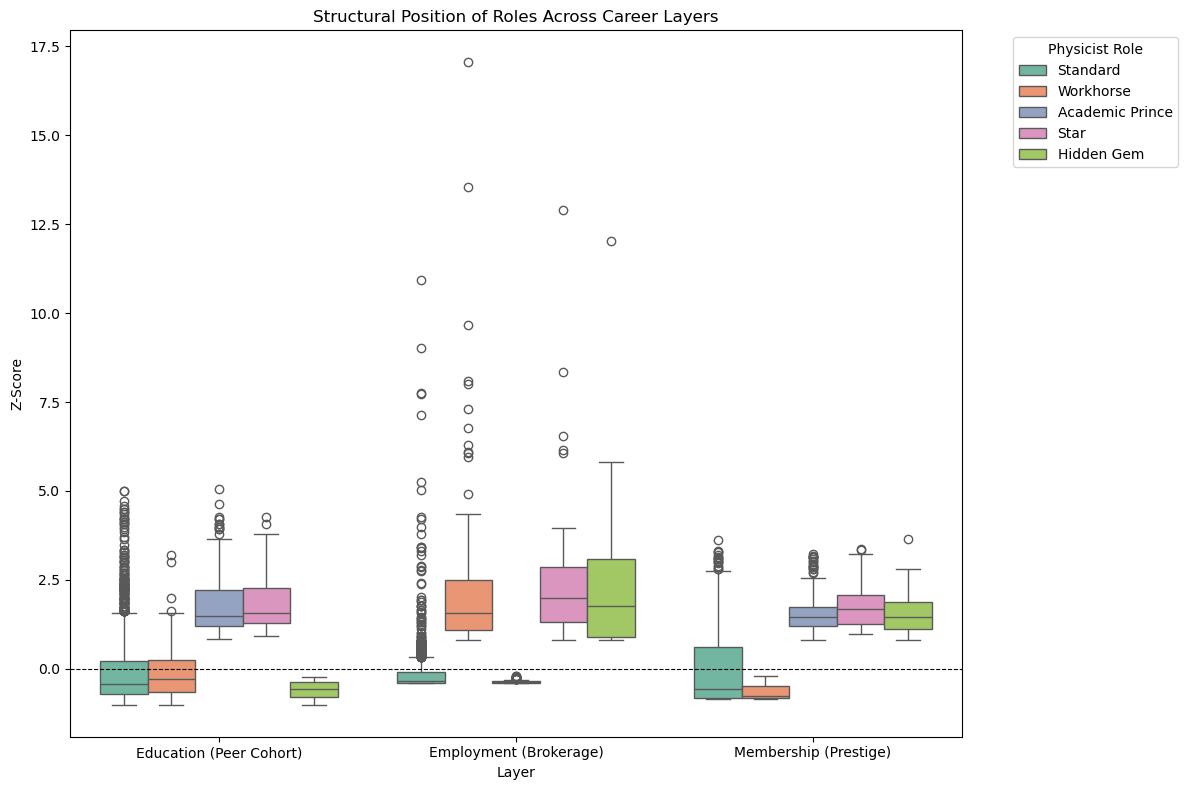

In [76]:
visualize_role_structures(results_dataframe)

### 1. What is a Z-Score?
A **Z-score** (or standard score) measures how many **standard deviations** a data point is away from the mean (average) of the group.

**Formula:**
$$Z = \frac{x - \mu}{\sigma}$$
*   $x$: The raw value (e.g., a physicist's Betweenness score).
*   $\mu$ (mu): The average of all scores in that graph.
*   $\sigma$ (sigma): The standard deviation (how spread out the scores are).

**Interpretation:**
*   **$Z = 0$**: The physicist is exactly average.
*   **$Z = +1.0$**: The physicist is **1 standard deviation above** the average (top ~16% in a normal distribution).
*   **$Z = -1.0$**: The physicist is **1 standard deviation below** the average.
*   **$Z = +2.5$**: The physicist is an extreme outlier (very high centrality).

---

### 2. Why is it critical in this specific analysis?

You are comparing three completely different mathematical metrics:
1.  **Degree Centrality (Education):** Values range from **0.0 to 1.0**. (e.g., Average might be 0.05).
2.  **Betweenness Centrality (Employment):** Values can range from **0.0 to 0.5** (or higher depending on graph size), but the distribution is usually very skewed. (e.g., Average might be 0.002).
3.  **PageRank/Eigenvector (Membership):** Values are relative weights that sum to 1. Individual scores are often tiny decimals like **0.0004**.

#### The Problem: "Apples vs. Oranges"
If you try to compare them directly without Z-scores:
*   Physicist A has Degree = **0.8** (Huge in Education).
*   Physicist A has Betweenness = **0.003** (Looks tiny in Employment).
*   Physicist A has PageRank = **0.0001** (Looks tiny in Membership).

If you sum these raw numbers, **Education dominates completely** because 0.8 is mathematically larger than 0.003. You would incorrectly conclude that Education is the most important factor, simply because its scale is larger.

#### The Solution: Z-Score Normalization
Z-scores convert all three metrics to a **common scale** based on *relative standing* within their own graph.

*   **Degree 0.8** might be $Z = +3.0$ (Top tier in Education).
*   **Betweenness 0.003** might *also* be $Z = +3.0$ (Top tier in Employment, even though the number looks small).
*   **PageRank 0.0001** might be $Z = +3.0$ (Top tier in Membership).

Now, you can fairly say: *"This physicist is in the top tier in ALL THREE layers,"* allowing you to correctly identify them as a **Star**.

---

### 3. How it Enables Role Classification
Your classification logic relies on thresholds like `HIGH = 0.8` and `LOW = -0.2`. These thresholds **only make sense** with Z-scores.

*   **Without Z-scores:** What is a "high" PageRank? Is 0.0005 high? Is 0.005 high? It depends entirely on the specific graph size and density. You would have to guess a new threshold for every dataset.
*   **With Z-scores:**
    *   `Z > 0.8` always means "significantly above average" (roughly top 20%).
    *   `Z < -0.2` always means "slightly below average".
    *   This makes your code **robust** and **portable**. You can run the same script on data from 1800 or 1980, and the definition of "Star" remains statistically consistent.


### Inspect profiles

In [247]:
### Role in relation to country

crosstab = pd.crosstab(df_pa['role'],df_pa['country'] )


In [248]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


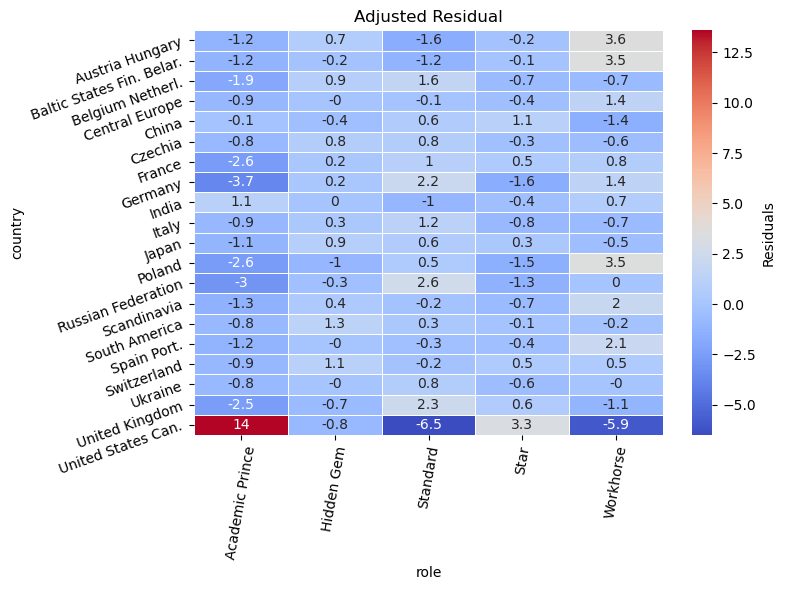

In [249]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 6))

In [250]:
## role in relation to period
crosstab = pd.crosstab(df_pa['role'],df_pa['per_activ'] )


In [251]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


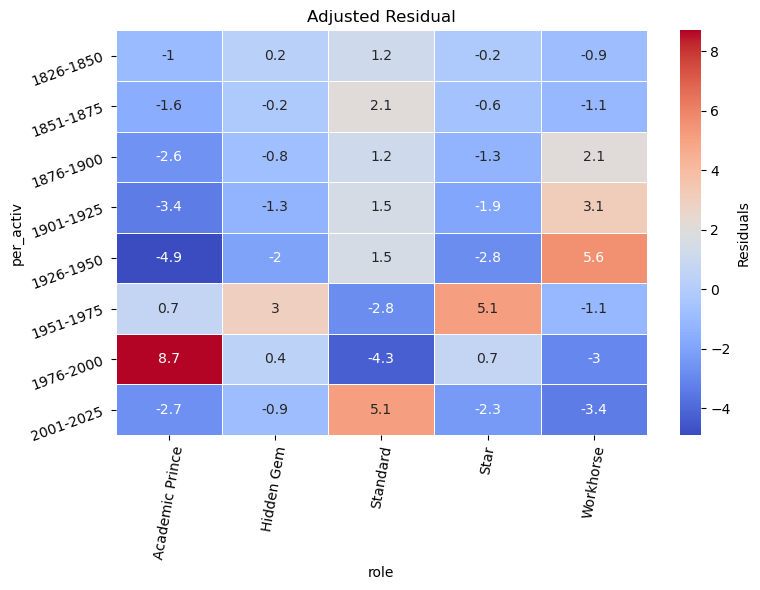

In [252]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 6))

In [257]:
df_pa_filtered=df_pa[df_pa['role'] =='Academic Prince']
crosstab = pd.crosstab(df_pa_filtered['per_activ'],df_pa_filtered['country'] )


In [258]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


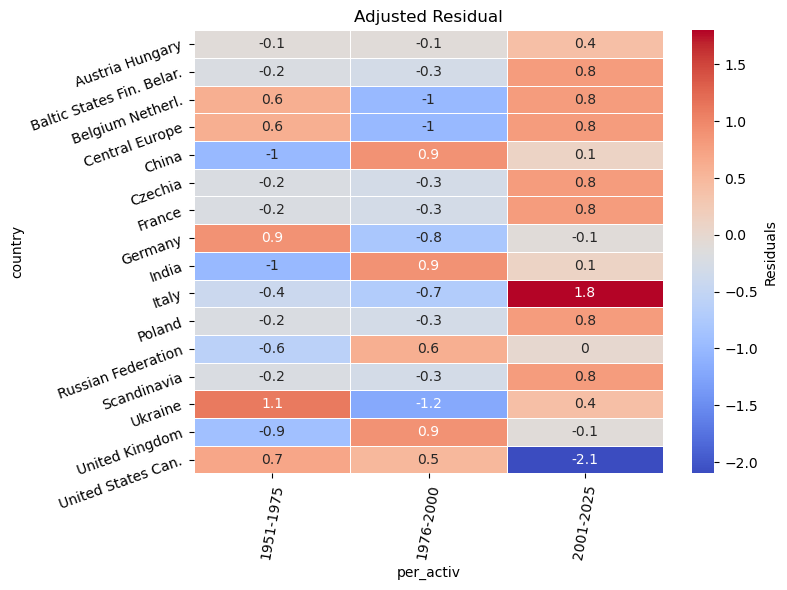

In [259]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 6))

#### Add roles to graphs

In [104]:
### Prepare data to add to nodes
# The data must be of type : dictionary, i.e. key:value structure
lna = dict([(e['uri'],
     {'edu_z':e['edu_z'],
     'emp_z':e['emp_z'],
     'mem_z':e['mem_z'],
     'role':e['role']
     }
     ) for e in df_pa.to_dict(orient='records')])

In [105]:

## Add attributes
nx.set_node_attributes(GA_edu, lna)
pprint.pprint(list(GA_edu.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q100155322',
  {'birthYear': 1953,
   'country': 'Czechia',
   'degree': 35,
   'degree_centrality': 0.010501050105010502,
   'edu_z': 1.4948420249515684,
   'emp_z': -0.3838088092143863,
   'gender': 'male',
   'label': 'Edgar Knobloch',
   'mem_z': -0.8290271756084421,
   'per_activ': '1976-2000',
   'role': 'Standard'}),
 ('http://www.wikidata.org/entity/Q106949',
  {'birthYear': 1959,
   'country': 'United States Can.',
   'degree': 45,
   'degree_centrality': 0.013501350135013503,
   'edu_z': 2.2089358052112726,
   'emp_z': -0.38649597568417554,
   'gender': 'male',
   'label': 'Saul Perlmutter',
   'mem_z': 0.5334129081024482,
   'per_activ': '2001-2025',
   'role': 'Standard'})]


In [106]:

## Add attributes
nx.set_node_attributes(GA_empl, lna)
pprint.pprint(list(GA_empl.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q111028460',
  {'birthYear': 1909,
   'country': 'United States Can.',
   'edu_z': 0.5665201106139526,
   'emp_z': 2.444312578263248,
   'gender': 'male',
   'label': 'John B. Irwin',
   'mem_z': -0.4588394687119764,
   'per_activ': '1951-1975',
   'role': 'Workhorse'}),
 ('http://www.wikidata.org/entity/Q115462',
  {'birthYear': 1898,
   'country': 'Central Europe',
   'edu_z': -0.5760299378015744,
   'emp_z': -0.3439054226198615,
   'gender': 'male',
   'label': 'Fritz Zwicky',
   'mem_z': -0.7013432615560494,
   'per_activ': '1926-1950',
   'role': 'Standard'})]


In [107]:

## Add attributes
nx.set_node_attributes(GA_memb, lna)
pprint.pprint(list(GA_memb.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q100216',
  {'birthYear': 1949,
   'country': 'Germany',
   'edu_z': -0.6474393158275448,
   'emp_z': -0.29124416589717894,
   'gender': 'male',
   'label': 'Willi Kalender',
   'mem_z': -0.6285683508575863,
   'per_activ': '1976-2000',
   'role': 'Standard'}),
 ('http://www.wikidata.org/entity/Q103854',
  {'birthYear': 1922,
   'country': 'Scandinavia',
   'edu_z': 0.20947322048410053,
   'emp_z': 0.48277633338405845,
   'gender': 'male',
   'label': 'Aage Bohr',
   'mem_z': 1.6710612081450573,
   'per_activ': '1951-1975',
   'role': 'Standard'})]


## Centrality distributions

### Education

#### Degree centrality (edu)

In [108]:
### Add degree centrality to nodes
degree = dict([(d[0], {'degree': d[1]}) for d in nx.degree(GA_edu)])
nx.set_node_attributes(GA_edu, degree)
pprint.pprint(list(GA_edu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q100155322',
  {'birthYear': 1953,
   'country': 'Czechia',
   'degree': 35,
   'degree_centrality': 0.010501050105010502,
   'edu_z': 1.4948420249515684,
   'emp_z': -0.3838088092143863,
   'gender': 'male',
   'label': 'Edgar Knobloch',
   'mem_z': -0.8290271756084421,
   'per_activ': '1976-2000',
   'role': 'Standard'}),
 ('http://www.wikidata.org/entity/Q106949',
  {'birthYear': 1959,
   'country': 'United States Can.',
   'degree': 45,
   'degree_centrality': 0.013501350135013503,
   'edu_z': 2.2089358052112726,
   'emp_z': -0.38649597568417554,
   'gender': 'male',
   'label': 'Saul Perlmutter',
   'mem_z': 0.5334129081024482,
   'per_activ': '2001-2025',
   'role': 'Standard'})]


In [109]:
### Statistical features of the degree
print(pd.Series([d[1] for d in nx.degree(GA_edu)]).describe())

count    3334.000000
mean       14.066587
std        14.003763
min         0.000000
25%         4.000000
50%         9.000000
75%        21.000000
max        85.000000
dtype: float64


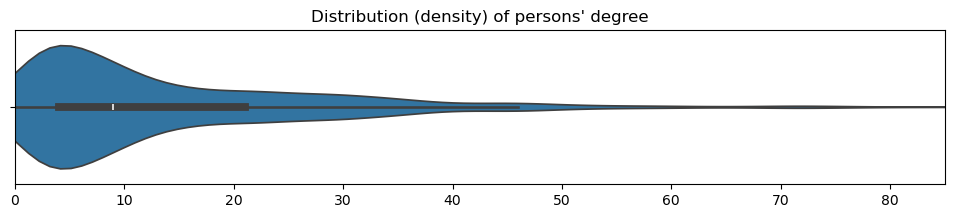

In [110]:
# Plot the distribution of degree centrality density

degree=[d[1] for d in nx.degree(GA_edu)]

min_val = min(degree)
max_val = max(degree)

plt.figure(figsize=(12, 2))
ax = sns.violinplot(data=degree, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of persons\' degree')
plt.show()

In [103]:
### Add degree centrality to nodes
degree_centrality = nx.degree_centrality(GA_edu)
nx.set_node_attributes(GA_edu, degree_centrality, 'degree_centrality')
pprint.pprint(list(GA_edu.nodes.data())[10:12])


[('http://www.wikidata.org/entity/Q19665429',
  {'birthYear': 1947,
   'country': 'Germany',
   'degree': 49,
   'degree_centrality': 0.014701470147014702,
   'gender': 'male',
   'label': 'Klaus Schulten',
   'per_activ': '1976-2000',
   'role': 'Standard'}),
 ('http://www.wikidata.org/entity/Q21932506',
  {'birthYear': 1952,
   'country': 'United States Can.',
   'degree': 59,
   'degree_centrality': 0.017701770177017705,
   'gender': 'female',
   'label': 'Debra Elmegreen',
   'per_activ': '1976-2000',
   'role': 'Academic Prince'})]


In [97]:
### Graph to heavy to use Gephy online

# BEWARE : these can be very heavy graphs and shold not be committed to git!!!

nx.write_gexf(GA_edu, f"da_graphs/GA_edu.gexf")

### Inspect individuals

In [113]:
### Export node attributes to dataframe
nodes_data ={node: GA_edu.nodes[node] for node in GA_edu.nodes}
nodes_df = pd.DataFrame(nodes_data).T
nodes_df.reset_index(inplace=True)
nodes_df.columns = ['personUri', 'label', 'birthYear', 'gender', 'per_activ', 'country', 
 'role','degree','degree_centrality', 'edu_z','emp_z','mem_z']
nodes_df.head(2)


,personUri,label,birthYear,gender,per_activ,country,role,degree,degree_centrality,edu_z,emp_z,mem_z
0,http://www.wikidata.org/entity/Q100155322,Edgar Knobloch,1953,male,1976-2000,Czechia,Standard,35,0.010501,1.494842,-0.383809,-0.829027
1,http://www.wikidata.org/entity/Q106949,Saul Perlmutter,1959,male,2001-2025,United States Can.,Standard,45,0.013501,2.208936,-0.386496,0.533413


#### Explore degree centrality on gr_edu

In [114]:
nodes_df.sort_values(by='degree', ascending=False).iloc[30:40]

,personUri,label,birthYear,gender,per_activ,country,role,degree,degree_centrality,edu_z,emp_z,mem_z
1080,http://www.wikidata.org/entity/Q28370110,Gerald Mahan,1937,male,1976-2000,United States Can.,Academic Prince,69,0.020702,3.922761,-0.388294,1.682946
279,http://www.wikidata.org/entity/Q260040,David Schramm,1945,male,1976-2000,United States Can.,Academic Prince,69,0.020702,3.922761,-0.281712,1.434753
842,http://www.wikidata.org/entity/Q61045,David J. Wineland,1944,male,1976-2000,United States Can.,Standard,68,0.020402,3.851351,0.221351,1.464735
1066,http://www.wikidata.org/entity/Q1065151,Charles Kennel,1939,male,1976-2000,United States Can.,Star,67,0.020102,3.779942,1.60751,1.638104
604,http://www.wikidata.org/entity/Q656931,Joseph W. Goodman,1936,male,1976-2000,United States Can.,Academic Prince,67,0.020102,3.779942,-0.369755,1.190574
291,http://www.wikidata.org/entity/Q5080476,Charles M. Newman,1946,male,1976-2000,United States Can.,Standard,66,0.019802,3.708533,0.023812,1.364418
611,http://www.wikidata.org/entity/Q1645447,Jerry Nelson,1944,male,1976-2000,United States Can.,Academic Prince,65,0.019502,3.637123,-0.387149,0.995768
4,http://www.wikidata.org/entity/Q1517797,Sajeev John,1957,male,2001-2025,India,Standard,65,0.019502,3.637123,-0.388062,-0.799333
456,http://www.wikidata.org/entity/Q217486,Walter Gilbert,1932,male,1976-2000,United States Can.,Star,64,0.019202,3.565714,0.944398,1.941765
1224,http://www.wikidata.org/entity/Q348149,Marc Davis,1947,male,1976-2000,United States Can.,Academic Prince,64,0.019202,3.565714,-0.377285,3.030444


In [119]:
duckdb.query("""
    SELECT label,degree, birthYear,country,per_activ,role,edu_z,emp_z, mem_z
    FROM nodes_df
    ORDER BY degree DESC
    LIMIT 10
""").to_df()

,label,degree,birthYear,country,per_activ,role,edu_z,emp_z,mem_z
0,Mildred Dresselhaus,85,1930,United States Can.,1951-1975,Academic Prince,5.065311,-0.365383,1.806699
1,Andrew Strominger,84,1955,United Kingdom,1976-2000,Standard,4.993902,-0.209966,0.682641
2,John N. Bahcall,84,1934,United States Can.,1976-2000,Standard,4.993902,-0.050987,1.724420
3,Raymond Stora,80,1930,France,1951-1975,Standard,4.708264,0.305098,-0.557920
4,Tom Lubensky,79,1943,United States Can.,1976-2000,Academic Prince,4.636855,-0.247389,1.498013
5,David Latham,78,1940,United States Can.,1976-2000,Standard,4.565445,-0.109907,2.683436
6,Lars Hernquist,77,1954,United States Can.,1976-2000,Standard,4.494036,0.409570,0.759046
7,Alan Lightman,77,1948,United States Can.,1976-2000,Standard,4.494036,-0.140843,0.797366
8,Susan Coppersmith,76,1957,United States Can.,2001-2025,Standard,4.422627,-0.267665,0.553754
9,Marshall Rosenbluth,76,1927,United States Can.,1951-1975,Standard,4.422627,0.704421,1.719472


In [124]:
duckdb.query("""
    SELECT label,degree, birthYear,country,per_activ,role,edu_z,emp_z, mem_z
    FROM nodes_df
    WHERE label LIKE '%Einstein%'
             or label LIKE '%Bohr%'
             or label LIKE '%Planck%'
    ORDER BY degree DESC
    LIMIT 10
""").to_df()

,label,degree,birthYear,country,per_activ,role,edu_z,emp_z,mem_z
0,Aage Bohr,17,1922,Scandinavia,1951-1975,Standard,0.209473,0.482776,1.671061
1,Niels Bohr,16,1885,Scandinavia,1926-1950,Workhorse,0.138064,1.123006,-0.406342
2,Christian Bohr,10,1855,Scandinavia,1876-1900,Standard,-0.290392,-0.348114,-0.843872
3,Max Planck,10,1858,Germany,1901-1925,Standard,-0.290392,0.666752,-0.825108
4,Albert Einstein,6,1879,Germany,1901-1925,Workhorse,-0.576030,6.073731,-0.631082


In [260]:
gr_edu_degree_1000=nodes_df.sort_values(by='degree', ascending=False).iloc[:1000]
#gr_edu_degree_1000.head(2)
df=gr_edu_degree_1000
# Create the crosstab
crosstab = pd.crosstab(df['country'], df['per_activ'])


In [261]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


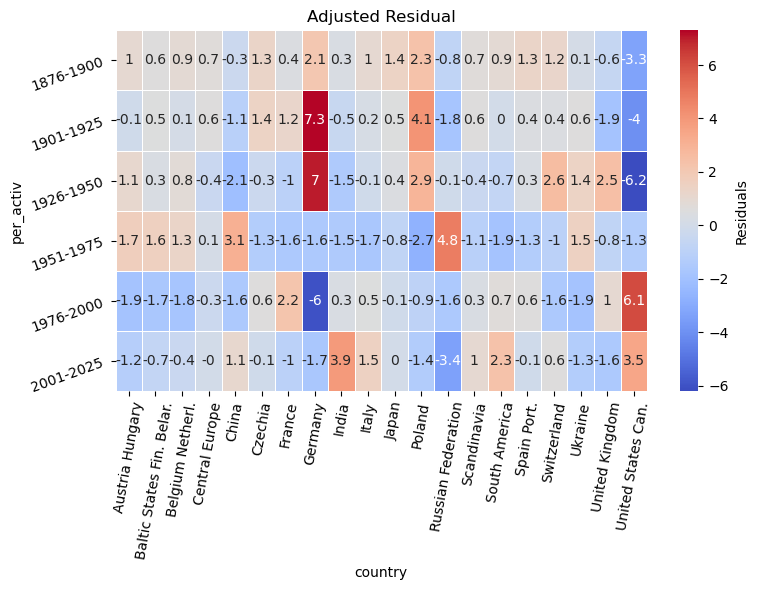

In [262]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 6))

In [263]:
gr_edu_degree_1000.head(2)

,personUri,label,birthYear,gender,per_activ,country,role,degree,degree_centrality,edu_z,emp_z,mem_z
235,http://www.wikidata.org/entity/Q29573,Mildred Dresselhaus,1930,female,1951-1975,United States Can.,Academic Prince,85,0.025503,5.065311,-0.365383,1.806699
473,http://www.wikidata.org/entity/Q710842,John N. Bahcall,1934,male,1976-2000,United States Can.,Standard,84,0.025203,4.993902,-0.050987,1.72442


### Get the most relevant educational institutions

In [199]:

node_list = set(gr_edu_degree_1000.personUri)

edges_data = [
    {
        'source': u,
        'target': v,
        'orgsLabels': d.get('orgsLabels'),
        'orgsNumber': d.get('orgsNumber')

    } 
    for u, v, d in GA_edu.edges(data=True) 
    if u in node_list or v in node_list
]

df_edu_1000_edges = pd.DataFrame(edges_data, columns=['source', 'target', 'orgsLabels', 'orgsNumber'])

In [200]:
df_edu_1000_edges[df_edu_1000_edges.orgsNumber>1].head()

,source,target,orgsLabels,orgsNumber
42,http://www.wikidata.org/entity/Q106949,http://www.wikidata.org/entity/Q16185277,"Harvard University|University of California, B...",2
63,http://www.wikidata.org/entity/Q106949,http://www.wikidata.org/entity/Q507732,"Harvard University|University of California, B...",2
96,http://www.wikidata.org/entity/Q1173616,http://www.wikidata.org/entity/Q2850406,Stanford University|Harvard University,2
110,http://www.wikidata.org/entity/Q1173616,http://www.wikidata.org/entity/Q753059,Stanford University|Harvard University,2
119,http://www.wikidata.org/entity/Q1384920,http://www.wikidata.org/entity/Q15804812,Harvard University|Princeton University,2


In [149]:
# Explode the pipe-separated values into separate rows
df_exploded = df_edu_1000_edges.assign(orgsLabels=df_edu_1000_edges['orgsLabels'].str.split('|')).explode('orgsLabels')
df_exploded.iloc[:3]


,source,target,orgsLabels,orgsNumber
0,http://www.wikidata.org/entity/Q100155322,http://www.wikidata.org/entity/Q106949,Harvard University,1
1,http://www.wikidata.org/entity/Q100155322,http://www.wikidata.org/entity/Q1173616,Harvard University,1
2,http://www.wikidata.org/entity/Q100155322,http://www.wikidata.org/entity/Q1384920,Harvard University,1


In [151]:
df_exploded[df_exploded.orgsNumber>1].iloc[:3]

,source,target,orgsLabels,orgsNumber
42,http://www.wikidata.org/entity/Q106949,http://www.wikidata.org/entity/Q16185277,Harvard University,2
42,http://www.wikidata.org/entity/Q106949,http://www.wikidata.org/entity/Q16185277,"University of California, Berkeley",2
63,http://www.wikidata.org/entity/Q106949,http://www.wikidata.org/entity/Q507732,Harvard University,2


In [153]:
# Strip whitespace and remove NaNs
df_exploded['orgsLabels'] = df_exploded['orgsLabels'].str.strip()
df_exploded = df_exploded.dropna(subset=['orgsLabels'])

# Count occurrences
university_counts = df_exploded['orgsLabels'].value_counts()

print(university_counts.iloc[:30])

orgsLabels
Harvard University                                                 2627
Massachusetts Institute of Technology                              2017
University of Cambridge                                            1579
University of California, Berkeley                                 1460
California Institute of Technology                                 1342
Princeton University                                               1028
MSU Faculty of Physics                                              892
Lomonosov Moscow State University                                   740
University of Chicago                                               697
University of Göttingen                                             636
Humboldt-Universität zu Berlin                                      573
Cornell University                                                  535
Peter the Great Saint Petersburg State Polytechnical University     465
Stanford University                                  

### Slice graph using k-cores

Cf. this [notebook for the methodology](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/analyse_reseaux/networkx_slicing_with_cores.ipynb)

In [154]:
### Get k-cores

### A k-core is a maximal subgraph that contains nodes of degree k or more.
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.core.core_number.html#networkx.algorithms.core.core_number

core_numbers = nx.core_number(GA_edu)
print(str(core_numbers)[:150])



{'http://www.wikidata.org/entity/Q100155322': 25, 'http://www.wikidata.org/entity/Q106949': 21, 'http://www.wikidata.org/entity/Q1173616': 21, 'http:/


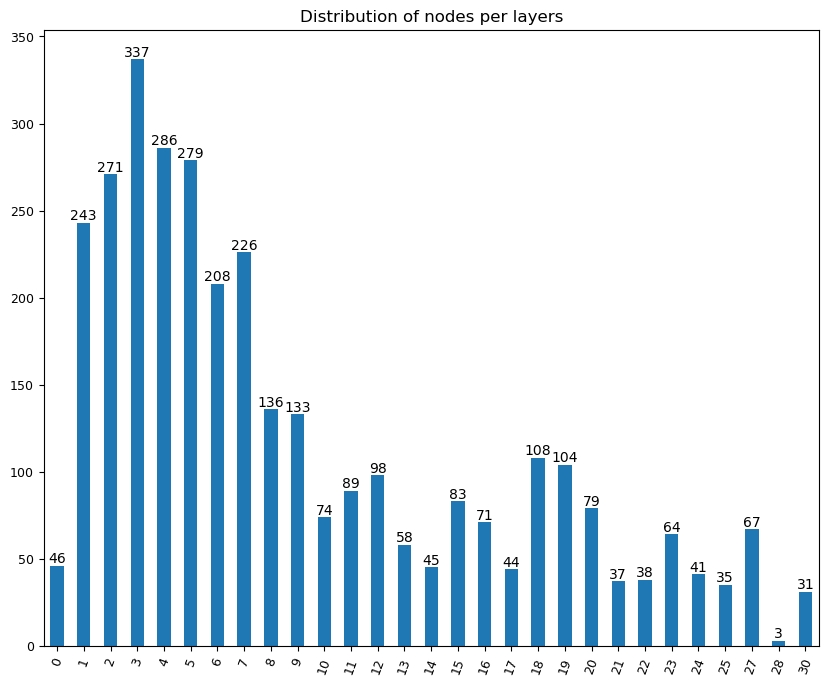

In [155]:
### Distribution of nodes per core layer
l = [v for k,v in core_numbers.items()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()


ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of nodes per layers')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()

In [156]:
# Identify layers based on core numbers
layers = {}
for node, core_number in core_numbers.items():
    if core_number not in layers:
        layers[core_number] = [node]
    else:
        layers[core_number].append(node)

In [157]:
cts = []
for core_number, layer in layers.items():
    # print(f"layers {core_number}: {len(layer)}")
    cts.append([core_number,len(layer),layer])



cts=sorted(cts, key=lambda x: x[0])
p=[pprint.pprint([e[0],e[1],e[2][:1] ]) for e in cts]

    

[0, 46, ['http://www.wikidata.org/entity/Q75523']]
[1, 243, ['http://www.wikidata.org/entity/Q100949981']]
[2, 271, ['http://www.wikidata.org/entity/Q58493243']]
[3, 337, ['http://www.wikidata.org/entity/Q94010']]
[4, 286, ['http://www.wikidata.org/entity/Q2732848']]
[5, 279, ['http://www.wikidata.org/entity/Q100216']]
[6, 208, ['http://www.wikidata.org/entity/Q18353093']]
[7, 226, ['http://www.wikidata.org/entity/Q100694']]
[8, 136, ['http://www.wikidata.org/entity/Q1995380']]
[9, 133, ['http://www.wikidata.org/entity/Q1252357']]
[10, 74, ['http://www.wikidata.org/entity/Q109337488']]
[11, 89, ['http://www.wikidata.org/entity/Q233355']]
[12, 98, ['http://www.wikidata.org/entity/Q86736']]
[13, 58, ['http://www.wikidata.org/entity/Q12998']]
[14, 45, ['http://www.wikidata.org/entity/Q339393']]
[15, 83, ['http://www.wikidata.org/entity/Q102054']]
[16, 71, ['http://www.wikidata.org/entity/Q2159263']]
[17, 44, ['http://www.wikidata.org/entity/Q17123859']]
[18, 108, ['http://www.wikidata.org

nx.k_core: This function  performs an iterative peeling. If a node has degree 4 in the original graph but is connected to a node that gets removed, its degree drops. If it drops below 4, k_core removes it too. This continues until stability. This produces the true 4-core.

In [161]:
### Same result by using the k_core function
kc_G = nx.k_core(GA_edu, 8)
naf.basic_graph_properties(kc_G)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 1438,
 'number_of_edges': 17654,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.01708667125434208}


In [162]:
### Graph to heavy to use Gephy online

# BEWARE : these can be very heavy graphs and shold not be committed to git!!!

nx.write_gexf(kc_G, f"da_graphs/GA_edu_k8.gexf")

## Explore the employment relationships graph

### Centrality distributions

#### Eigenvector centrality

In [163]:
### Add eigenvector to nodes

## If error: PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
# increase number of max iterations
eigenvector = nx.eigenvector_centrality(GA_empl, max_iter=200)
nx.set_node_attributes(GA_empl, eigenvector, 'eigenvector')
pprint.pprint(list(GA_empl.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q111028460',
  {'birthYear': 1909,
   'country': 'United States Can.',
   'edu_z': 0.5665201106139526,
   'eigenvector': 0.04737817208759483,
   'emp_z': 2.444312578263248,
   'gender': 'male',
   'label': 'John B. Irwin',
   'mem_z': -0.4588394687119764,
   'per_activ': '1951-1975',
   'role': 'Workhorse'}),
 ('http://www.wikidata.org/entity/Q115462',
  {'birthYear': 1898,
   'country': 'Central Europe',
   'edu_z': -0.5760299378015744,
   'eigenvector': 0.01123546139455762,
   'emp_z': -0.3439054226198615,
   'gender': 'male',
   'label': 'Fritz Zwicky',
   'mem_z': -0.7013432615560494,
   'per_activ': '1926-1950',
   'role': 'Standard'})]


In [164]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series(list(eigenvector.values()))
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    3334.00000000000000000000
mean        0.00765698889219114127
std         0.01553650325853384202
min         0.00000000000000000000
25%         0.00006993272970239278
50%         0.00074369070587256502
75%         0.00626937417734136238
max         0.12728950196592045407
dtype: object


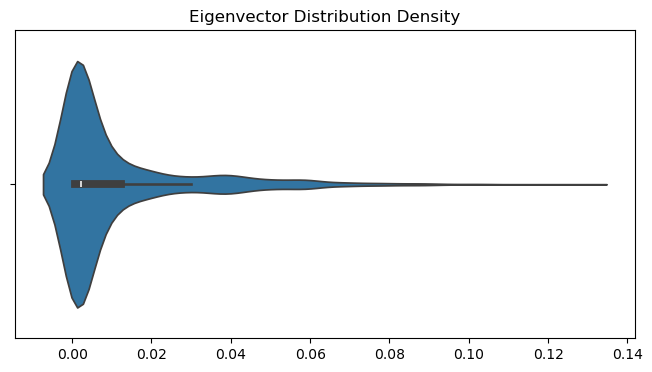

In [165]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=eigenvector_s[eigenvector_s> 0.00013610493515402787], orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

#### Betweenness centrality

In [166]:
### Add betweenness to nodes
# Parameters for approximation: k=500, seed=42 and speed up

betweenness = nx.betweenness_centrality(GA_empl, k=500, seed=42)
nx.set_node_attributes(GA_empl, betweenness, 'betweenness')
pprint.pprint(list(GA_empl.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q111028460',
  {'betweenness': 0.004543247352552729,
   'birthYear': 1909,
   'country': 'United States Can.',
   'edu_z': 0.5665201106139526,
   'eigenvector': 0.04737817208759483,
   'emp_z': 2.444312578263248,
   'gender': 'male',
   'label': 'John B. Irwin',
   'mem_z': -0.4588394687119764,
   'per_activ': '1951-1975',
   'role': 'Workhorse'}),
 ('http://www.wikidata.org/entity/Q115462',
  {'betweenness': 8.733571160543109e-05,
   'birthYear': 1898,
   'country': 'Central Europe',
   'edu_z': -0.5760299378015744,
   'eigenvector': 0.01123546139455762,
   'emp_z': -0.3439054226198615,
   'gender': 'male',
   'label': 'Fritz Zwicky',
   'mem_z': -0.7013432615560494,
   'per_activ': '1926-1950',
   'role': 'Standard'})]


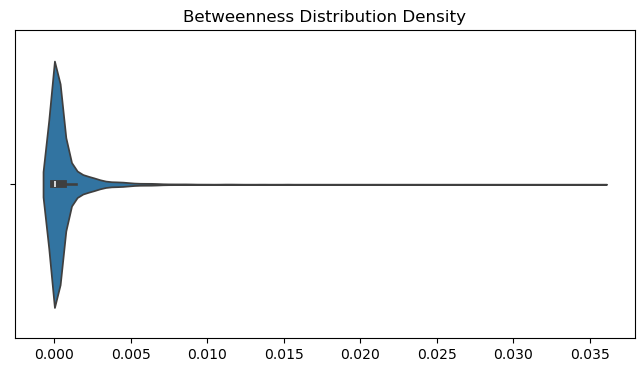

In [171]:
# Plot the distribution of eigenbetweenness vector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=betweenness, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [177]:
### Export node attributes to dataframe
nodes_data ={node: GA_empl.nodes[node] for node in GA_empl.nodes}
nodes_df_empl = pd.DataFrame(nodes_data).T
nodes_df_empl.reset_index(inplace=True)
nodes_df_empl.columns = ['personUri', 'label', 'birthYear', 'gender', 'per_activ', 'country', 
 'role', 'edu_z','emp_z','mem_z','eigenvector','betweenness']

In [265]:
## Dataframe with the features of the nodes
nodes_df_empl.head(3)

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
0,http://www.wikidata.org/entity/Q111028460,John B. Irwin,1909,male,1951-1975,United States Can.,Workhorse,0.56652,2.444313,-0.458839,0.047378,0.004543
1,http://www.wikidata.org/entity/Q115462,Fritz Zwicky,1898,male,1926-1950,Central Europe,Standard,-0.57603,-0.343905,-0.701343,0.011235,0.000087
2,http://www.wikidata.org/entity/Q1240217,Donald Edward Osterbrock,1924,male,1951-1975,United States Can.,Standard,1.209205,-0.050671,2.37669,0.018492,0.000297


#### Explore eigenvector on gr_empl

In [179]:
nodes_df_empl.sort_values(by='eigenvector', ascending=False).iloc[:5]

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
73,http://www.wikidata.org/entity/Q184980,Thomas Kuhn,1922,male,1951-1975,United States Can.,Star,1.066386,2.828628,1.61943,0.12729,0.005184
54,http://www.wikidata.org/entity/Q12270113,Richard McCray,1937,male,1976-2000,United States Can.,Star,0.923567,1.540284,2.684298,0.105338,0.002931
679,http://www.wikidata.org/entity/Q325584,George B. Field,1929,male,1951-1975,United States Can.,Star,2.494573,0.845621,2.762306,0.101784,0.00193
224,http://www.wikidata.org/entity/Q1901962,Marlan Scully,1939,male,1976-2000,United States Can.,Standard,-0.004755,3.38909,1.941593,0.101738,0.005888
78,http://www.wikidata.org/entity/Q203461,Gerson Goldhaber,1924,male,1951-1975,Germany,Hidden Gem,-0.361802,1.757387,1.624769,0.098462,0.004098


In [198]:
gr_empl_eigenv_1000=nodes_df_empl.sort_values(by='eigenvector', ascending=False).iloc[:1000]
gr_empl_eigenv_1000.head(2)

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
73,http://www.wikidata.org/entity/Q184980,Thomas Kuhn,1922,male,1951-1975,United States Can.,Star,1.066386,2.828628,1.61943,0.12729,0.005184
54,http://www.wikidata.org/entity/Q12270113,Richard McCray,1937,male,1976-2000,United States Can.,Star,0.923567,1.540284,2.684298,0.105338,0.002931


In [266]:
df=gr_empl_eigenv_1000
# Create the crosstab
crosstab = pd.crosstab(df['country'], df['per_activ'])


In [182]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


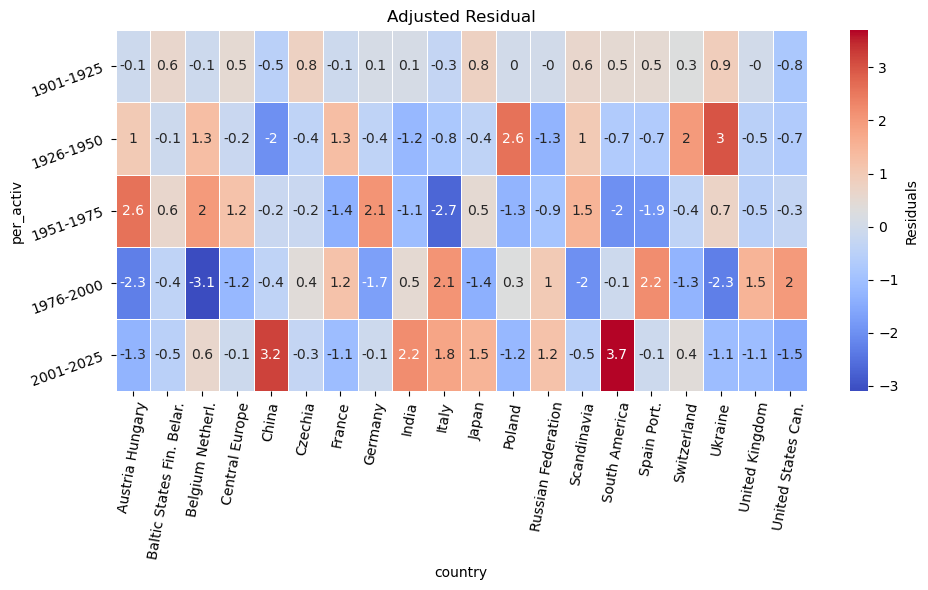

In [267]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

In [185]:
crosstab

per_activ,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025
country,,,,,
Austria Hungary,1,7,22,9,2
Baltic States Fin. Belar.,0,1,4,3,0
Belgium Netherl.,1,8,21,7,6
Central Europe,0,1,5,2,1
China,0,0,12,13,10
Czechia,0,0,2,3,0
France,0,5,5,12,1
Germany,2,8,34,22,8
India,0,0,4,8,5


### Get the most relevant employment institutions

In [268]:

node_list = set(gr_empl_eigenv_1000.personUri)

edges_data = [
    {
        'source': u,
        'target': v,
        'orgsLabels': d.get('orgsLabels'),
        'orgsNumber': d.get('orgsNumber')

    } 
    for u, v, d in GA_empl.edges(data=True) 
    if u in node_list or v in node_list
]

df_empl_eigenv_1000 = pd.DataFrame(edges_data, columns=['source', 'target', 'orgsLabels', 'orgsNumber'])

In [269]:
# Explode the pipe-separated values into separate rows
df_exploded = df_empl_eigenv_1000.assign(orgsLabels=df_empl_eigenv_1000['orgsLabels'].str.split('|')).explode('orgsLabels')
# Strip whitespace and remove NaNs
df_exploded['orgsLabels'] = df_exploded['orgsLabels'].str.strip()
df_exploded = df_exploded.dropna(subset=['orgsLabels'])

# Count occurrences
university_counts = df_exploded['orgsLabels'].value_counts()

print(university_counts.iloc[:30])

orgsLabels
Harvard University                         7645
Massachusetts Institute of Technology      5860
University of California, Berkeley         5794
California Institute of Technology         3352
Princeton University                       3295
Leiden University                          2645
University of Chicago                      2157
University of Cambridge                    1918
Stanford University                        1847
Cornell University                         1755
Bell Labs                                  1130
Columbia University                         990
University of California, San Diego         826
CERN                                        607
University of Arizona                       582
University of Illinois Urbana-Champaign     564
University of Göttingen                     502
University of Michigan                      494
University of California, Santa Barbara     489
Yale University                             459
University of Texas at Austin

#### Explore betweenness on gr_empl

In [190]:
nodes_df_empl.sort_values(by='betweenness', ascending=False).iloc[:5]

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
368,http://www.wikidata.org/entity/Q465488,Leopold Infeld,1898,male,1926-1950,Poland,Workhorse,-0.57603,17.045245,-0.746999,0.011257,0.035364
43,http://www.wikidata.org/entity/Q974437,Paul Sophus Epstein,1883,male,1926-1950,Poland,Workhorse,0.994976,13.538226,-0.631918,0.008761,0.026713
340,http://www.wikidata.org/entity/Q950897,Yakov Sinai,1935,male,1976-2000,Russian Federation,Star,1.637661,12.910369,2.357351,0.022389,0.02652
339,http://www.wikidata.org/entity/Q948991,Elliott Waters Montroll,1916,male,1951-1975,United States Can.,Hidden Gem,-1.004486,12.030265,1.232781,0.05212,0.02338
327,http://www.wikidata.org/entity/Q780498,Isaak Khalatnikov,1919,male,1951-1975,Ukraine,Standard,-0.004755,9.013143,0.109226,0.01571,0.020445


In [191]:
gr_empl_betweenness_1000=nodes_df_empl.sort_values(by='betweenness', ascending=False).iloc[:1000]
gr_empl_betweenness_1000.head(2)

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
368,http://www.wikidata.org/entity/Q465488,Leopold Infeld,1898,male,1926-1950,Poland,Workhorse,-0.57603,17.045245,-0.746999,0.011257,0.035364
43,http://www.wikidata.org/entity/Q974437,Paul Sophus Epstein,1883,male,1926-1950,Poland,Workhorse,0.994976,13.538226,-0.631918,0.008761,0.026713


In [270]:
df=gr_empl_betweenness_1000
# Create the crosstab
crosstab = pd.crosstab(df['country'], df['per_activ'])


In [271]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


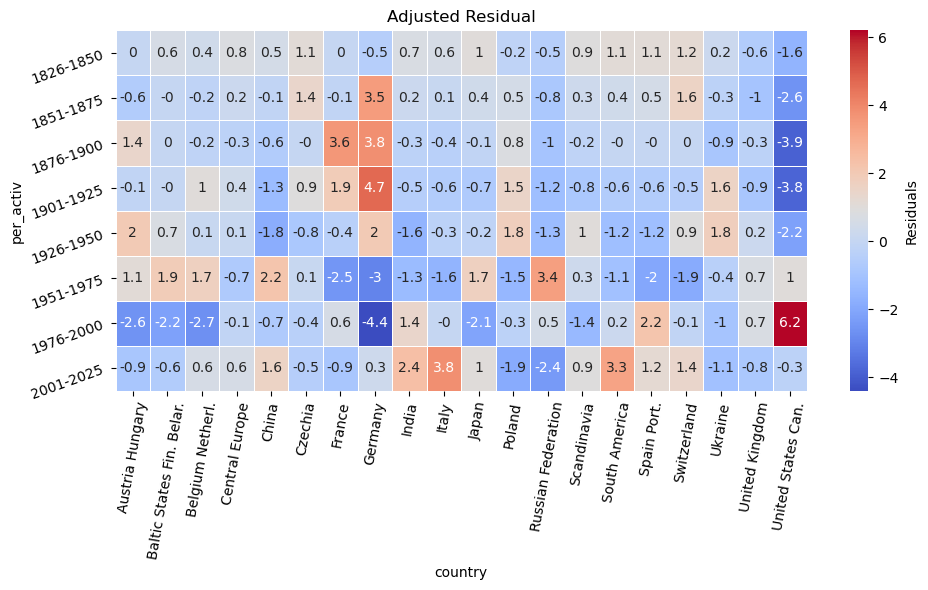

In [272]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

### Get the most intermediary employment institutions

In [195]:

node_list = set(gr_empl_betweenness_1000.personUri)

edges_data = [
    {
        'source': u,
        'target': v,
        'orgsLabels': d.get('orgsLabels'),
        'orgsNumber': d.get('orgsNumber')

    } 
    for u, v, d in GA_empl.edges(data=True) 
    if u in node_list or v in node_list
]

df_empl_eigenv_1000 = pd.DataFrame(edges_data, columns=['source', 'target', 'orgsLabels', 'orgsNumber'])

In [196]:
# Explode the pipe-separated values into separate rows
df_exploded = df_empl_eigenv_1000.assign(orgsLabels=df_empl_eigenv_1000['orgsLabels'].str.split('|')).explode('orgsLabels')
# Strip whitespace and remove NaNs
df_exploded['orgsLabels'] = df_exploded['orgsLabels'].str.strip()
df_exploded = df_exploded.dropna(subset=['orgsLabels'])

# Count occurrences
university_counts = df_exploded['orgsLabels'].value_counts()

print(university_counts.iloc[:30])

orgsLabels
Harvard University                            6893
University of California, Berkeley            5251
Massachusetts Institute of Technology         4629
Princeton University                          2919
California Institute of Technology            2665
Leiden University                             2495
Lomonosov Moscow State University             2493
University of Chicago                         1894
University of Cambridge                       1860
University of Göttingen                       1659
Stanford University                           1562
Cornell University                            1449
Columbia University                            860
Humboldt-Universität zu Berlin                 851
Bell Labs                                      850
University of California, San Diego            699
Ludwig-Maximilians-Universität München         665
Moscow Institute of Physics and Technology     618
Lebedev Physical Institute                     606
University of Warsaw

### Create a subgraph with high eigenvector centrality scores

In [208]:
centrality = {node: data.get('eigenvector', 0) for node, data in GA_empl.nodes(data=True)}
# Extract scores
scores = list(centrality.values())

In [210]:
# Calculate third quartile (75th percentile)
threshold = np.percentile(scores, 75)

# Select nodes above the threshold
nodes_to_keep = [node for node, score in centrality.items() if score > threshold]

# Create subgraph
subGA_empl = GA_empl.subgraph(nodes_to_keep)
naf.basic_graph_properties(subGA_empl)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 834,
 'number_of_edges': 39151,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.11270983213429256}


In [211]:
### Graph to heavy to use Gephy online

# BEWARE : these can be very heavy graphs and shold not be committed to git!!!

nx.write_gexf(subGA_empl, f"da_graphs/subGA_empl.gexf")

## Explore the membership relationships graph

### Centrality distributions

#### Eigenvector centrality

In [273]:
### Add eigenvector to nodes

## If error: PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
# increase number of max iterations
eigenvector = nx.eigenvector_centrality(GA_memb, max_iter=200)
nx.set_node_attributes(GA_memb, eigenvector, 'eigenvector')
pprint.pprint(list(GA_memb.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q100216',
  {'betweenness': 1.6276069465271627e-05,
   'birthYear': 1949,
   'country': 'Germany',
   'edu_z': -0.6474393158275448,
   'eigenvector': 0.0022999990518714165,
   'emp_z': -0.29124416589717894,
   'gender': 'male',
   'label': 'Willi Kalender',
   'mem_z': -0.6285683508575863,
   'per_activ': '1976-2000',
   'role': 'Standard'}),
 ('http://www.wikidata.org/entity/Q103854',
  {'betweenness': 0.001991376546626203,
   'birthYear': 1922,
   'country': 'Scandinavia',
   'edu_z': 0.20947322048410053,
   'eigenvector': 0.04052625396924468,
   'emp_z': 0.48277633338405845,
   'gender': 'male',
   'label': 'Aage Bohr',
   'mem_z': 1.6710612081450573,
   'per_activ': '1951-1975',
   'role': 'Standard'})]


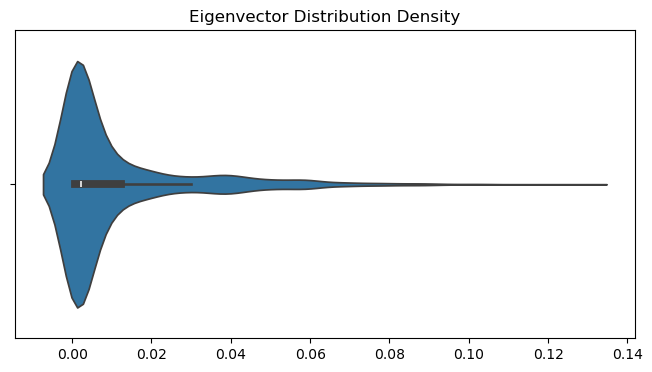

In [274]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=eigenvector_s[eigenvector_s> 0.00013610493515402787], orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [ ]:
### Add betweenness to nodes
# Parameters for approximation: k=500, seed=42 and speed up

betweenness = nx.betweenness_centrality(GA_memb, k=500, seed=42)
nx.set_node_attributes(GA_memb, betweenness, 'betweenness')
pprint.pprint(list(GA_memb.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q100216',
  {'betweenness': 1.6276069465271627e-05,
   'birthYear': 1949,
   'country': 'Germany',
   'edu_z': -0.6474393158275448,
   'eigenvector': 0.0022999990518714165,
   'emp_z': -0.29124416589717894,
   'gender': 'male',
   'label': 'Willi Kalender',
   'mem_z': -0.6285683508575863,
   'per_activ': '1976-2000',
   'role': 'Standard'}),
 ('http://www.wikidata.org/entity/Q103854',
  {'betweenness': 0.001991376546626203,
   'birthYear': 1922,
   'country': 'Scandinavia',
   'edu_z': 0.20947322048410053,
   'eigenvector': 0.04052625396924468,
   'emp_z': 0.48277633338405845,
   'gender': 'male',
   'label': 'Aage Bohr',
   'mem_z': 1.6710612081450573,
   'per_activ': '1951-1975',
   'role': 'Standard'})]


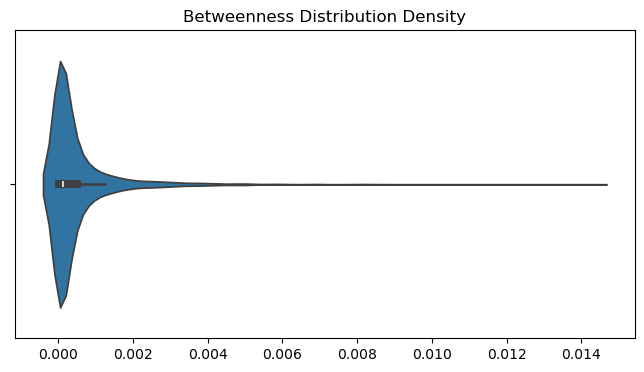

In [275]:
# Plot the distribution of eigenbetweenness vector density
betweenness_s = pd.Series(list(betweenness.values()))

plt.figure(figsize=(8,4))
p = sns.violinplot(data=betweenness_s, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [276]:
### Export node attributes to dataframe
nodes_data ={node: GA_memb.nodes[node] for node in GA_memb.nodes}
nodes_df_memb = pd.DataFrame(nodes_data).T
nodes_df_memb.reset_index(inplace=True)
nodes_df_memb.columns = ['personUri', 'label', 'birthYear', 'gender', 'per_activ', 'country', 
 'role', 'edu_z','emp_z','mem_z','eigenvector','betweenness']
nodes_df_memb.head(2)

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
0,http://www.wikidata.org/entity/Q100216,Willi Kalender,1949,male,1976-2000,Germany,Standard,-0.647439,-0.291244,-0.628568,0.0023,0.000016
1,http://www.wikidata.org/entity/Q103854,Aage Bohr,1922,male,1951-1975,Scandinavia,Standard,0.209473,0.482776,1.671061,0.040526,0.001991


#### Explore eigenvector on gr_memb

In [231]:
nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:5]

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
1023,http://www.wikidata.org/entity/Q728331,Jim Peebles,1935,male,1976-2000,United States Can.,Standard,0.709339,-0.350884,3.272112,0.047776,0.003267
95,http://www.wikidata.org/entity/Q76600,Manfred Eigen,1927,male,1951-1975,Germany,Standard,0.138064,0.342914,2.391134,0.04711,0.008093
666,http://www.wikidata.org/entity/Q193496,James Cronin,1931,male,1976-2000,United States Can.,Standard,0.709339,2.41695,2.245447,0.047085,0.004172
1058,http://www.wikidata.org/entity/Q83333,James Watson,1928,male,1951-1975,United States Can.,Star,1.494842,2.862964,2.349868,0.04701,0.006686
689,http://www.wikidata.org/entity/Q2038350,Roald Sagdeev,1932,male,1976-2000,Russian Federation,Star,2.85162,2.303227,3.100802,0.046966,0.005128


In [232]:
gr_memb_eigenv_1000=nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:1000]
gr_memb_eigenv_1000.head(2)

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
1023,http://www.wikidata.org/entity/Q728331,Jim Peebles,1935,male,1976-2000,United States Can.,Standard,0.709339,-0.350884,3.272112,0.047776,0.003267
95,http://www.wikidata.org/entity/Q76600,Manfred Eigen,1927,male,1951-1975,Germany,Standard,0.138064,0.342914,2.391134,0.04711,0.008093


In [277]:
### Most connected persons
df=gr_memb_eigenv_1000
# Create the crosstab
crosstab = pd.crosstab(df['country'], df['per_activ'])


In [278]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [279]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 130.11 , dof : 57
p-value : 0.0
Inertia (Phi-square):  0.13
Cramer:  0.208


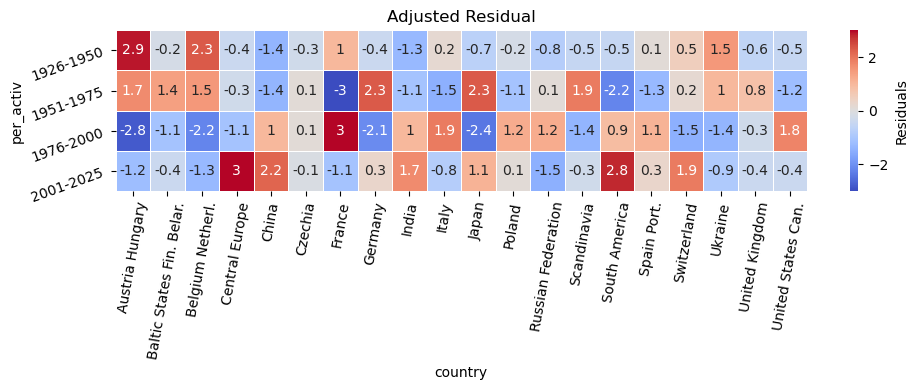

In [280]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 4))

### Get the most relevant membership institutions

In [281]:

node_list = set(gr_memb_eigenv_1000.personUri)

edges_data = [
    {
        'source': u,
        'target': v,
        'orgsLabels': d.get('orgsLabels'),
        'orgsNumber': d.get('orgsNumber')

    } 
    for u, v, d in GA_memb.edges(data=True) 
    if u in node_list or v in node_list
]

df_memb_eigenv_1000 = pd.DataFrame(edges_data, columns=['source', 'target', 'orgsLabels', 'orgsNumber'])

In [282]:
# Explode the pipe-separated values into separate rows
df_exploded = df_memb_eigenv_1000.assign(orgsLabels=df_memb_eigenv_1000['orgsLabels'].str.split('|')).explode('orgsLabels')
# Strip whitespace and remove NaNs
df_exploded['orgsLabels'] = df_exploded['orgsLabels'].str.strip()
df_exploded = df_exploded.dropna(subset=['orgsLabels'])

# Count occurrences
university_counts = df_exploded['orgsLabels'].value_counts()

print(university_counts.iloc[:30])

orgsLabels
National Academy of Sciences                                    161701
American Academy of Arts and Sciences                           161110
International Astronomical Union                                 35596
Royal Society                                                    30638
American Physical Society                                        19025
Russian Academy of Sciences                                      16566
American Philosophical Society                                   13839
Academia Europaea                                                12558
German Academy of Sciences Leopoldina                             8613
Academy of Sciences of the USSR                                   4821
National Academy of Engineering                                   4214
French Academy of Sciences                                        3916
American Association for the Advancement of Science               2685
Royal Netherlands Academy of Arts and Sciences                    

In [283]:
nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:10]

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
1023,http://www.wikidata.org/entity/Q728331,Jim Peebles,1935,male,1976-2000,United States Can.,Standard,0.709339,-0.350884,3.272112,0.047776,0.003267
95,http://www.wikidata.org/entity/Q76600,Manfred Eigen,1927,male,1951-1975,Germany,Standard,0.138064,0.342914,2.391134,0.04711,0.008093
666,http://www.wikidata.org/entity/Q193496,James Cronin,1931,male,1976-2000,United States Can.,Standard,0.709339,2.41695,2.245447,0.047085,0.004172
1058,http://www.wikidata.org/entity/Q83333,James Watson,1928,male,1951-1975,United States Can.,Star,1.494842,2.862964,2.349868,0.04701,0.006686
689,http://www.wikidata.org/entity/Q2038350,Roald Sagdeev,1932,male,1976-2000,Russian Federation,Star,2.85162,2.303227,3.100802,0.046966,0.005128
442,http://www.wikidata.org/entity/Q1030228,Ludvig Faddeev,1934,male,1976-2000,Russian Federation,Standard,0.495111,1.935594,2.421271,0.046766,0.004998
636,http://www.wikidata.org/entity/Q1795596,Wallace L. W. Sargent,1935,male,1976-2000,United Kingdom,Standard,-0.504621,-0.376137,3.204859,0.046736,0.00219
503,http://www.wikidata.org/entity/Q1248892,Chintamani Nagesa Ramachandra Rao,1934,male,1976-2000,India,Standard,-0.57603,-0.388294,2.39911,0.046599,0.004824
647,http://www.wikidata.org/entity/Q187199,Carlo Rubbia,1934,male,1976-2000,Italy,Standard,-0.076164,-0.259867,2.382184,0.046455,0.004706
741,http://www.wikidata.org/entity/Q237825,John Polanyi,1929,male,1951-1975,Germany,Standard,-0.290392,-0.347355,2.168665,0.046265,0.003839


#### Explore betweenness on gr_memb

In [284]:
nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:5]

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
1090,http://www.wikidata.org/entity/Q181369,Chen-ning Yang,1922,male,1951-1975,China,Star,2.066117,6.151687,2.001881,0.044483,0.014268
116,http://www.wikidata.org/entity/Q907162,Vitalii Goldanskii,1923,male,1951-1975,Baltic States Fin. Belar.,Star,1.423433,0.879287,2.091726,0.04458,0.012372
65,http://www.wikidata.org/entity/Q567782,Bohdan Paczyński,1940,male,1976-2000,Baltic States Fin. Belar.,Standard,-0.147574,-0.37177,2.859984,0.038136,0.011727
648,http://www.wikidata.org/entity/Q187224,Pierre-Gilles de Gennes,1932,male,1976-2000,France,Hidden Gem,-0.218983,4.395118,2.218184,0.045876,0.010493
488,http://www.wikidata.org/entity/Q12116293,Chang-Lin Tien,1935,male,1976-2000,China,Academic Prince,0.994976,-0.327187,1.353334,0.035837,0.009032


In [285]:
gr_memb_betweenness_1000=nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:1000]
gr_memb_betweenness_1000.head(2)

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
1090,http://www.wikidata.org/entity/Q181369,Chen-ning Yang,1922,male,1951-1975,China,Star,2.066117,6.151687,2.001881,0.044483,0.014268
116,http://www.wikidata.org/entity/Q907162,Vitalii Goldanskii,1923,male,1951-1975,Baltic States Fin. Belar.,Star,1.423433,0.879287,2.091726,0.04458,0.012372


In [287]:
df=gr_memb_betweenness_1000
# Create the crosstab
crosstab = pd.crosstab(df['country'], df['per_activ'])


In [288]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


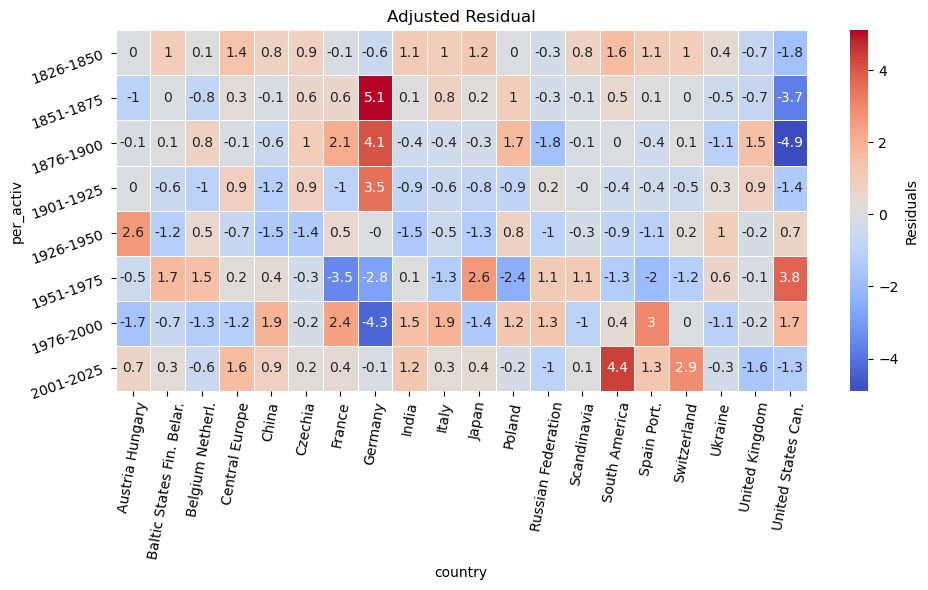

In [289]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

### Get the intermediary membership institutions

In [290]:

node_list = set(gr_memb_betweenness_1000.personUri)

edges_data = [
    {
        'source': u,
        'target': v,
        'orgsLabels': d.get('orgsLabels'),
        'orgsNumber': d.get('orgsNumber')

    } 
    for u, v, d in GA_memb.edges(data=True) 
    if u in node_list or v in node_list
]

df_memb_betweenness_1000 = pd.DataFrame(edges_data, columns=['source', 'target', 'orgsLabels', 'orgsNumber'])

In [291]:
# Explode the pipe-separated values into separate rows
df_exploded = df_memb_betweenness_1000.assign(orgsLabels=df_memb_betweenness_1000['orgsLabels'].str.split('|')).explode('orgsLabels')
# Strip whitespace and remove NaNs
df_exploded['orgsLabels'] = df_exploded['orgsLabels'].str.strip()
df_exploded = df_exploded.dropna(subset=['orgsLabels'])

# Count occurrences
university_counts = df_exploded['orgsLabels'].value_counts()

print(university_counts.iloc[:30])

orgsLabels
American Academy of Arts and Sciences                           141817
National Academy of Sciences                                    141183
Royal Society                                                    32948
International Astronomical Union                                 31668
Russian Academy of Sciences                                      22228
German Academy of Sciences Leopoldina                            17393
American Physical Society                                        16798
American Philosophical Society                                   16357
Academia Europaea                                                12589
Academy of Sciences of the USSR                                   5690
French Academy of Sciences                                        5376
Göttingen Academy of Sciences and Humanities in Lower Saxony      5074
National Academy of Engineering                                   3919
Accademia Nazionale dei Lincei                                    

In [292]:
nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:10]

,personUri,label,birthYear,gender,per_activ,country,role,edu_z,emp_z,mem_z,eigenvector,betweenness
1090,http://www.wikidata.org/entity/Q181369,Chen-ning Yang,1922,male,1951-1975,China,Star,2.066117,6.151687,2.001881,0.044483,0.014268
116,http://www.wikidata.org/entity/Q907162,Vitalii Goldanskii,1923,male,1951-1975,Baltic States Fin. Belar.,Star,1.423433,0.879287,2.091726,0.04458,0.012372
65,http://www.wikidata.org/entity/Q567782,Bohdan Paczyński,1940,male,1976-2000,Baltic States Fin. Belar.,Standard,-0.147574,-0.37177,2.859984,0.038136,0.011727
648,http://www.wikidata.org/entity/Q187224,Pierre-Gilles de Gennes,1932,male,1976-2000,France,Hidden Gem,-0.218983,4.395118,2.218184,0.045876,0.010493
488,http://www.wikidata.org/entity/Q12116293,Chang-Lin Tien,1935,male,1976-2000,China,Academic Prince,0.994976,-0.327187,1.353334,0.035837,0.009032
32,http://www.wikidata.org/entity/Q183509,Ilya Prigogine,1917,male,1951-1975,Russian Federation,Standard,-0.933077,0.412712,1.531118,0.038285,0.008664
24,http://www.wikidata.org/entity/Q164396,Victor Ambartsumian,1908,male,1951-1975,Russian Federation,Hidden Gem,-0.290392,1.509777,1.198903,0.031576,0.008549
133,http://www.wikidata.org/entity/Q103835,Peter Debye,1884,male,1926-1950,Belgium Netherl.,Workhorse,0.495111,7.312426,-0.444277,0.006566,0.008266
368,http://www.wikidata.org/entity/Q83331,Louis de Broglie,1892,male,1926-1950,France,Standard,-0.718849,-0.269233,-0.11339,0.012089,0.008212
95,http://www.wikidata.org/entity/Q76600,Manfred Eigen,1927,male,1951-1975,Germany,Standard,0.138064,0.342914,2.391134,0.04711,0.008093


### Produce subgraph

In [294]:
df_exploded[:2]

,source,target,orgsLabels,orgsNumber
0,http://www.wikidata.org/entity/Q100216,http://www.wikidata.org/entity/Q106547,German Academy of Sciences Leopoldina,1
1,http://www.wikidata.org/entity/Q100216,http://www.wikidata.org/entity/Q109372,German Academy of Sciences Leopoldina,1


In [297]:
l_persons=duckdb.query("""
    SELECT DISTINCT source as person_uri
    FROM df_exploded
    WHERE orgsLabels IN ('French Academy of Sciences', 'Royal Swedish Academy of Sciences', 
                       'Göttingen Academy of Sciences and Humanities in Lower Saxony', 
                       'Bavarian Academy of Sciences and Humanities', 'Royal Netherlands Academy of Arts and Sciences',
                       'German Academy of Sciences Leopoldina')
    UNION
    SELECT target as person_uri
    FROM df_exploded
    WHERE orgsLabels IN ('French Academy of Sciences', 'Royal Swedish Academy of Sciences', 
                       'Göttingen Academy of Sciences and Humanities in Lower Saxony', 
                       'Bavarian Academy of Sciences and Humanities', 'Royal Netherlands Academy of Arts and Sciences',
                       'German Academy of Sciences Leopoldina ')

""").to_df()
print(len(l_persons))
l_persons.head(2)

800


,person_uri
0,http://www.wikidata.org/entity/Q63632045
1,http://www.wikidata.org/entity/Q651059


In [298]:
### Extract the subgraph using only the 1000 nodes
# .copy() creates a new independent graph object
sub_G = GA_memb.subgraph(l_persons.person_uri.to_list()).copy()

# 4. Verify and Export
print(f"Subgraph nodes: {sub_G.number_of_nodes()}")
print(f"Subgraph edges: {sub_G.number_of_edges()}")

graph_address="da_graphs/subgraph_membership_betweenness.graphml"

# Export directly to Gephi format
nx.write_graphml(sub_G, graph_address)

Subgraph nodes: 800
Subgraph edges: 46645
